# 🏥 Breast Cancer Prediction Pipeline
### Feature Selection • Explainable AI • Machine Learning Model Comparison

*Comparaison rigoureuse de 3 modèles de classification (Régression Logistique, Random Forest, XGBoost) pour la détection du cancer du sein, avec sélection de variables multi-méthodes, optimisation bayésienne des hyperparamètres (Optuna) et explicabilité (SHAP).*

| Étape | Contenu |
|-------|---------|
| **0** | Imports & configuration |
| **1** | Chargement, inversion cible & EDA |
| **2** | Préparation — Split & Normalisation |
| **2bis** | Visualisation PCA (2D) |
| **3** | Sélection de variables — 4 méthodes (Filtre, Forward, Backward, LASSO) |
| **4** | Comparaison des méthodes & choix de la meilleure |
| **5** | Modèle 1 — Régression Logistique (+ CV, ROC, PR) |
| **6** | Modèle 2 — Random Forest + SHAP (+ CV, ROC, PR) |
| **7** | Modèle 3 — XGBoost + SHAP (+ CV, ROC, PR) |
| **8** | Comparaison finale & recommandation clinique |
| **8bis** | Comparaison des importances de variables (toutes méthodes) |
| **9** | Synthèse générale |
| **10** | Sauvegarde du modèle final (déploiement) |

> **Convention médicale** : `1 = Malin` · `0 = Bénin`
> **Priorité** : maximiser le **Recall** — ne manquer aucun cancer malin


## 0. 📦 Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

# Dataset & prétraitement
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_validate)
from sklearn.preprocessing import StandardScaler

# ── Sélection de variables ──────────────────────────────────────────────────
from sklearn.feature_selection import (SelectKBest, f_classif,
                                       mutual_info_classif)
from sklearn.linear_model import LassoCV, Lasso, LogisticRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# ── Modèles ────────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── Métriques ──────────────────────────────────────────────────────────────
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             recall_score, precision_score, brier_score_loss,
                             confusion_matrix, classification_report,
                             RocCurveDisplay, PrecisionRecallDisplay,
                             ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve

# ── Optimisation ───────────────────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── SHAP ───────────────────────────────────────────────────────────────────
try:
    import shap
    SHAP_OK = True
    print("✅ SHAP disponible")
except ImportError:
    SHAP_OK = False
    print("⚠️  SHAP non installé — pip install shap")

# Style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

RANDOM_STATE = 42
CV_FOLDS     = 5
N_TRIALS     = 60
K_FILTER     = 10     # Nombre de features à retenir (méthode filtre)

print("✅ Tous les imports sont OK !")

✅ SHAP disponible
✅ Tous les imports sont OK !


## 1. 📂 Chargement, Inversion & EDA

### 1.1 Chargement & inversion de la cible

In [2]:
data = load_breast_cancer()
df   = pd.DataFrame(data.data, columns=data.feature_names)

# ── Inversion convention médicale ──────────────────────────────────────────
# sklearn : 0 = malin, 1 = bénin  →  1 = malin, 0 = bénin
df['target'] = 1 - data.target

X = df.drop('target', axis=1)
y = df['target']

print("=" * 60)
print("  BREAST CANCER WISCONSIN DATASET")
print("=" * 60)
print(f"  Instances     : {df.shape[0]}")
print(f"  Features      : {X.shape[1]}")
print(f"  Malin   (1)   : {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")
print(f"  Bénin   (0)   : {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"  Valeurs manq. : {df.isnull().sum().sum()}")
df.head(3)

  BREAST CANCER WISCONSIN DATASET
  Instances     : 569
  Features      : 30
  Malin   (1)   : 212 (37.3%)
  Bénin   (0)   : 357 (62.7%)
  Valeurs manq. : 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1


### 1.2 Distribution de la variable cible

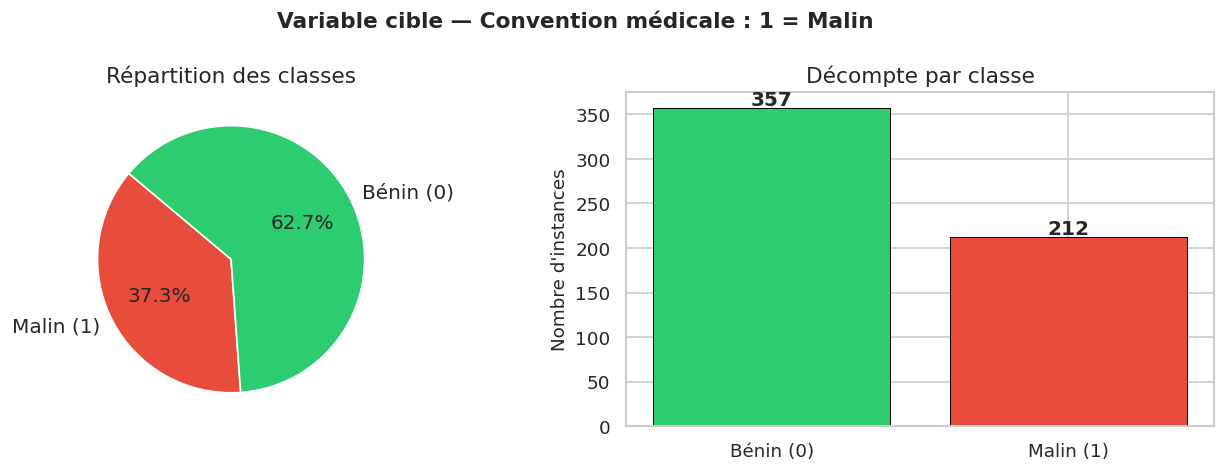

Dataset relativement équilibré. Le Recall reste la métrique prioritaire.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].pie([y.value_counts()[1], y.value_counts()[0]],
            labels=['Malin (1)', 'Bénin (0)'],
            colors=['#E74C3C','#2ECC71'],
            autopct='%1.1f%%', startangle=140,
            textprops={'fontsize': 12})
axes[0].set_title('Répartition des classes')

counts = y.value_counts().sort_index()
bars = axes[1].bar(['Bénin (0)', 'Malin (1)'],
                   [counts[0], counts[1]],
                   color=['#2ECC71','#E74C3C'], edgecolor='black', lw=0.6)
axes[1].set_title('Décompte par classe')
axes[1].set_ylabel("Nombre d'instances")
for bar in bars:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 str(int(bar.get_height())), ha='center',
                 fontsize=12, fontweight='bold')

plt.suptitle('Variable cible — Convention médicale : 1 = Malin',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Dataset relativement équilibré. Le Recall reste la métrique prioritaire.")

### 1.3 Distribution des features par classe

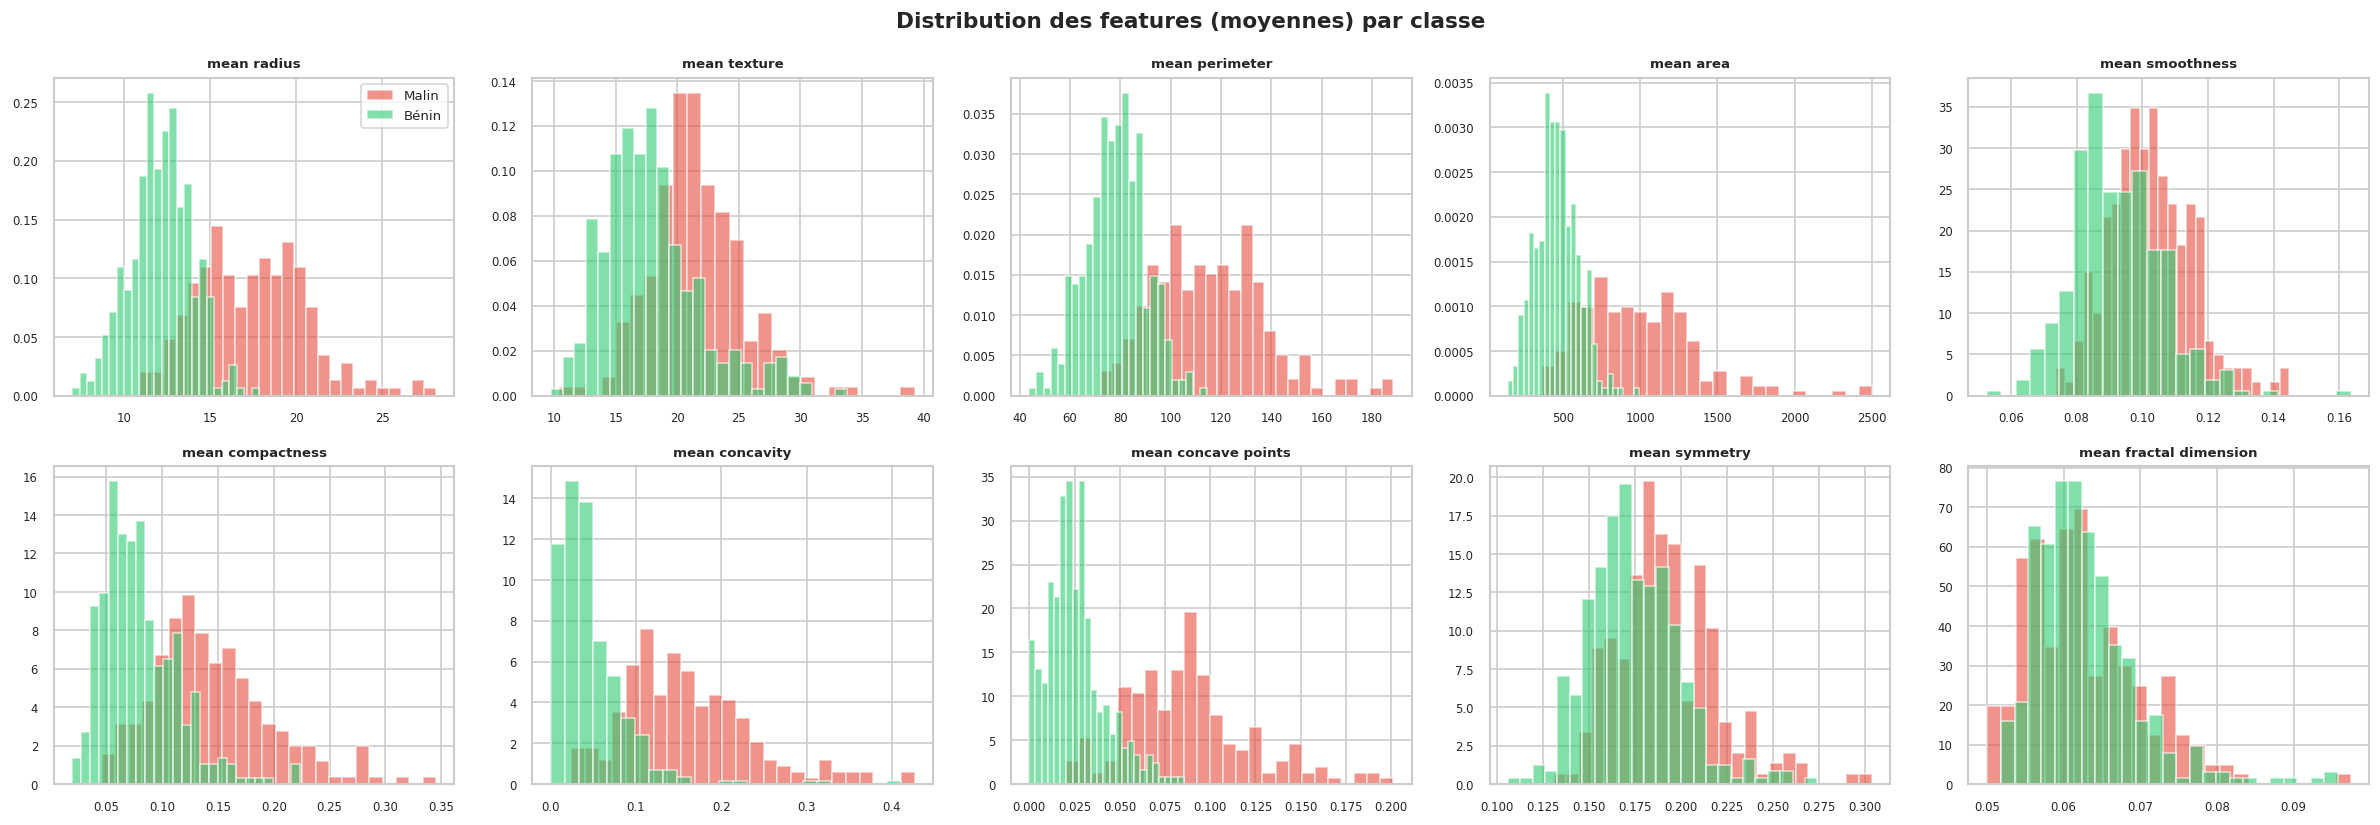

Tumeurs malignes : valeurs plus élevées pour radius, perimeter, area, concavity.


In [4]:
mean_features = [c for c in X.columns if 'mean' in c]
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for i, col in enumerate(mean_features):
    for cls, color, label in zip([1,0], ['#E74C3C','#2ECC71'], ['Malin','Bénin']):
        axes[i].hist(df[df['target']==cls][col], bins=25,
                     alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=8, fontweight='bold')
    axes[i].tick_params(labelsize=7)
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Distribution des features (moyennes) par classe',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Tumeurs malignes : valeurs plus élevées pour radius, perimeter, area, concavity.")

### 1.4 Corrélation des features avec la cible

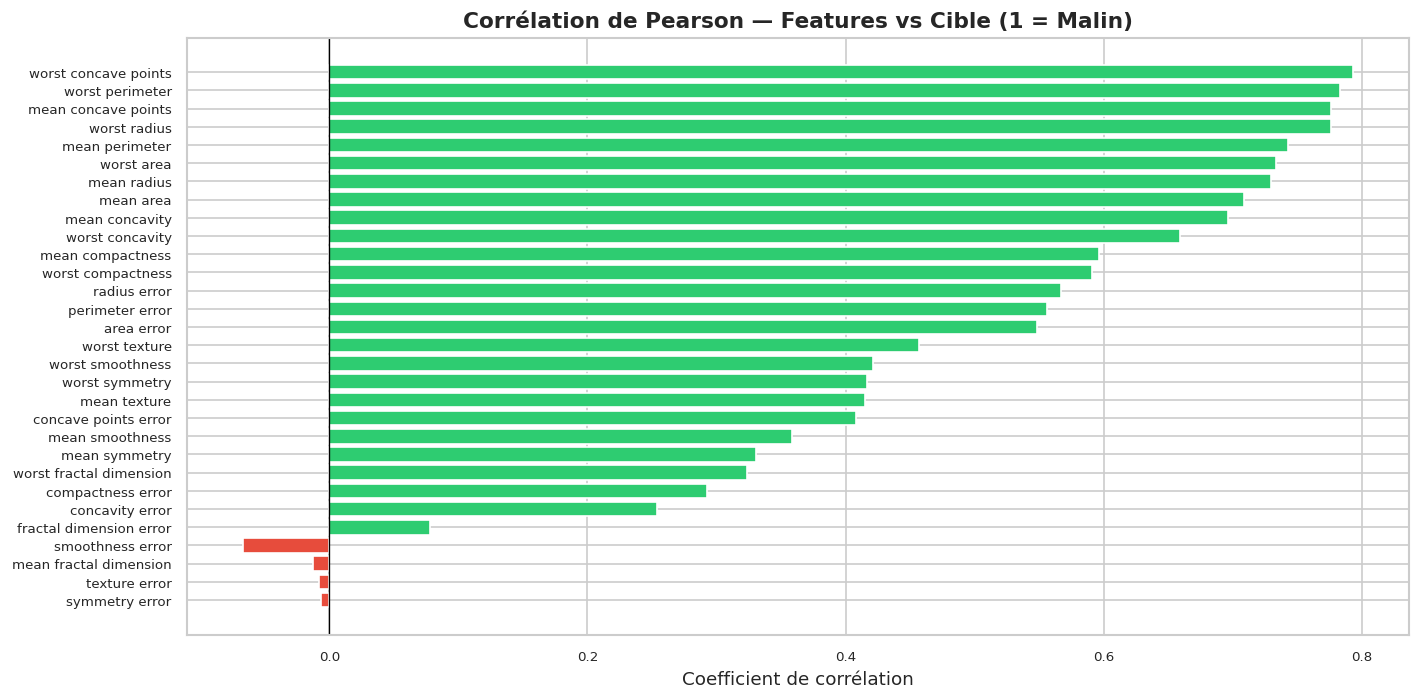

Top 5 features corrélées à la malignité :
  worst concave points                           r = 0.794
  worst perimeter                                r = 0.783
  mean concave points                            r = 0.777
  worst radius                                   r = 0.776
  mean perimeter                                 r = 0.743


In [5]:
corr_target = df.corr()['target'].drop('target').sort_values(key=abs, ascending=False)

plt.figure(figsize=(12, 6))
colors_bar = ['#E74C3C' if v < 0 else '#2ECC71' for v in corr_target]
plt.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors_bar[::-1])
plt.axvline(0, color='black', lw=0.8)
plt.title('Corrélation de Pearson — Features vs Cible (1 = Malin)', fontweight='bold')
plt.xlabel('Coefficient de corrélation')
plt.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

print("Top 5 features corrélées à la malignité :")
for feat in corr_target.abs().nlargest(5).index:
    print(f"  {feat:45s}  r = {corr_target[feat]:.3f}")

### 1.5 Matrice de corrélation inter-features

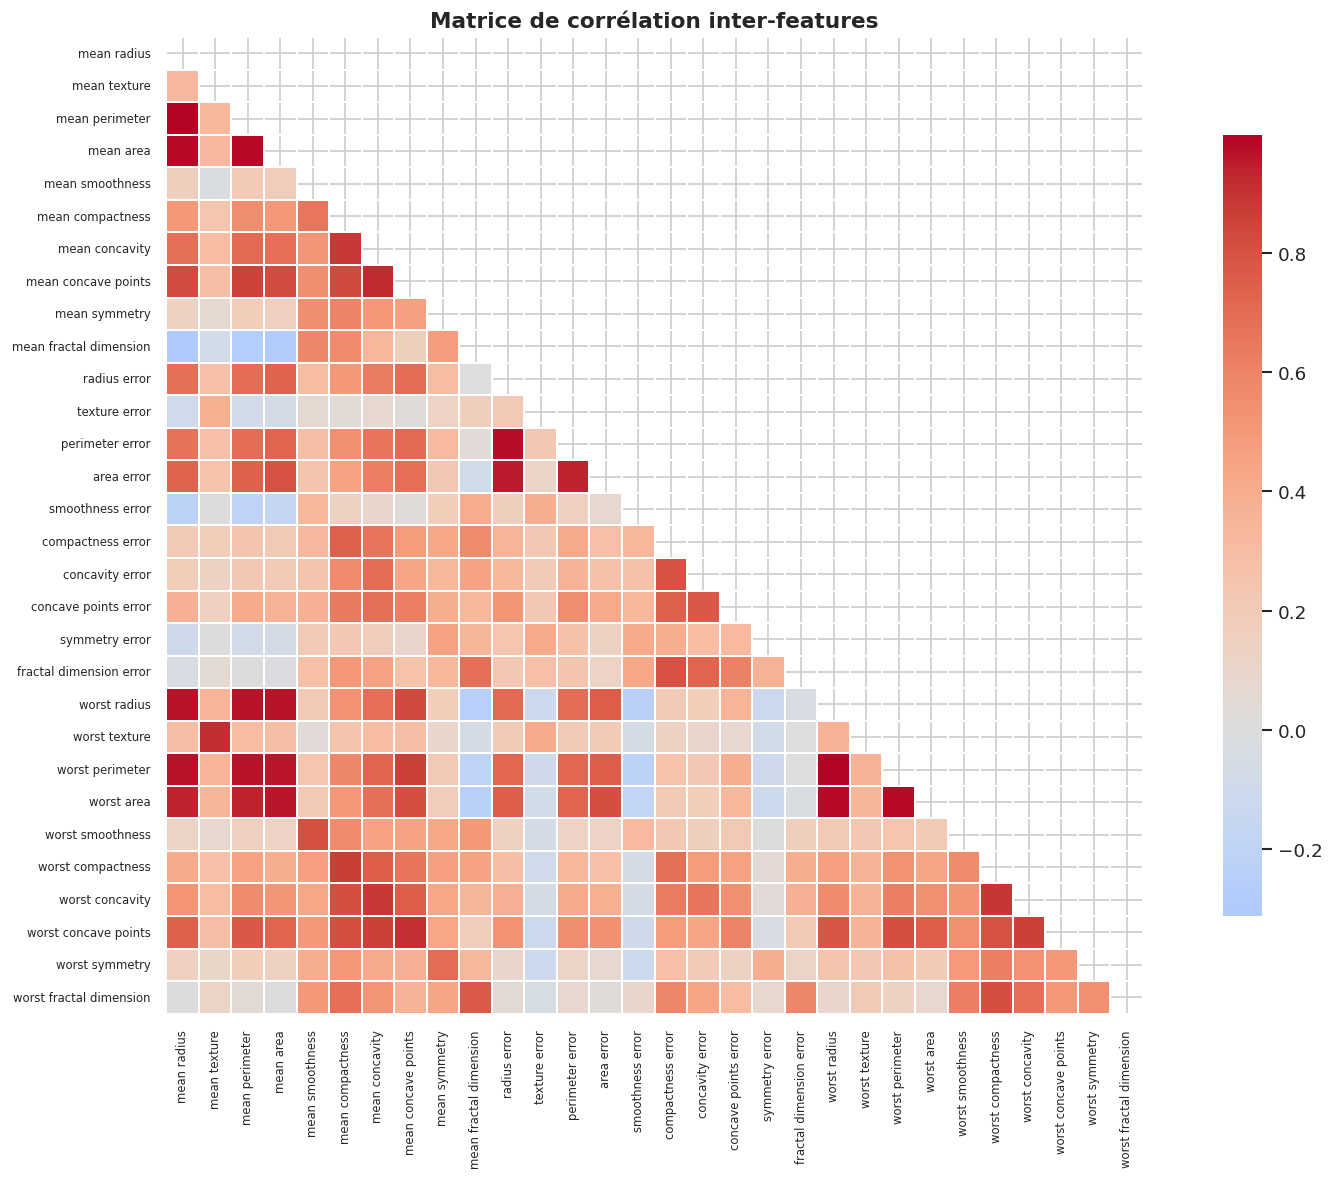

Paires avec |r| > 0.9 : 21
=> Forte multicolinéarité — justifie la comparaison de plusieurs méthodes de sélection.


In [6]:
corr_matrix = X.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.2, cbar_kws={'shrink': 0.8})
plt.title('Matrice de corrélation inter-features', fontweight='bold')
plt.tick_params(axis='x', rotation=90, labelsize=7)
plt.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

n_high = sum(1 for i in range(len(corr_matrix.columns))
             for j in range(i+1, len(corr_matrix.columns))
             if abs(corr_matrix.iloc[i,j]) > 0.9)
print(f"Paires avec |r| > 0.9 : {n_high}")
print("=> Forte multicolinéarité — justifie la comparaison de plusieurs méthodes de sélection.")

## 2. ⚙️ Préparation — Split & Normalisation

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
base_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

print(f"Train : {X_train_sc.shape[0]} | Test : {X_test_sc.shape[0]}")
print(f"Features initiales : {X_train_sc.shape[1]}")

selection_results = {}

Train : 455 | Test : 114
Features initiales : 30


## 2bis. 🧭 Visualisation PCA (2D)

Projection des 30 variables standardisées sur les 2 premières composantes principales, pour visualiser la séparabilité des classes Bénin / Malin.

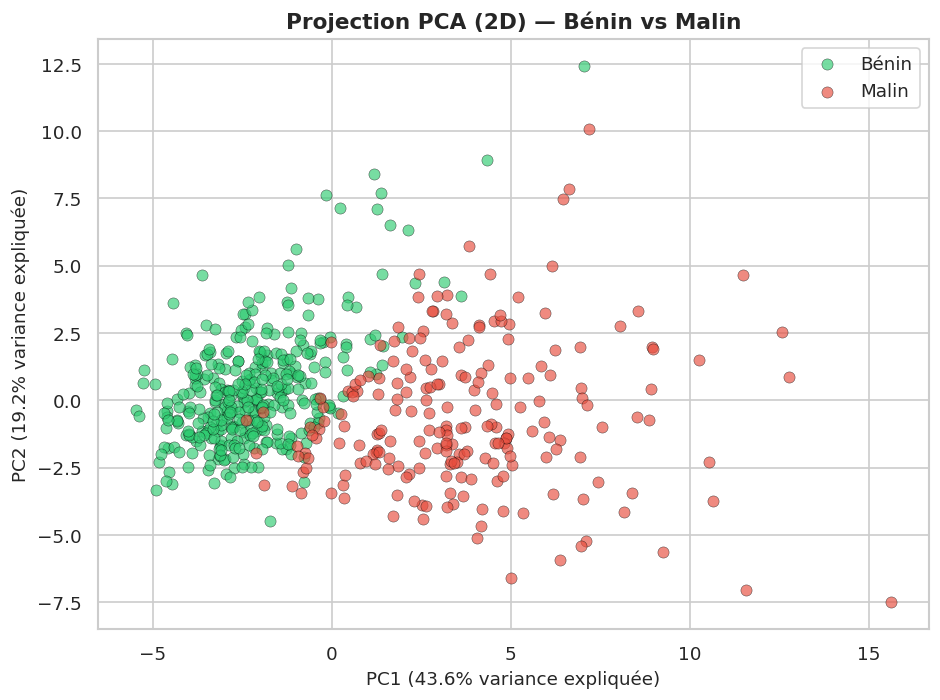

Variance totale expliquée par PC1+PC2 : 62.8%


In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(np.vstack([X_train_sc, X_test_sc]))
y_all = np.concatenate([y_train, y_test])

var_exp = pca.explained_variance_ratio_

plt.figure(figsize=(8, 6))
for label, color, name in [(0, '#2ECC71', 'Bénin'), (1, '#E74C3C', 'Malin')]:
    mask = y_all == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=name,
                alpha=0.65, edgecolor='black', linewidth=0.3, s=45)

plt.xlabel(f'PC1 ({var_exp[0]*100:.1f}% variance expliquée)')
plt.ylabel(f'PC2 ({var_exp[1]*100:.1f}% variance expliquée)')
plt.title('Projection PCA (2D) — Bénin vs Malin', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Variance totale expliquée par PC1+PC2 : {var_exp.sum()*100:.1f}%")


## 3. 🔎 Sélection de Variables 

Nous comparons quatre approches complémentaires :

| Méthode | Type | Principe |
|---------|------|----------|
| **Filtre (F-score + MI)** | Filter | Score chaque feature indépendamment via un test statistique |
| **Forward Selection** | Wrapper | Ajoute les features une à une selon l'amélioration du modèle |
| **Backward Elimination** | Wrapper | Retire les features une à une selon l'impact sur le modèle |
| **LASSO** | Embedded | Pénalisation L1 intégrée → force des coefficients à zéro |

### 3.1 Méthode Filtre (ANOVA F-score + Information Mutuelle)

In [9]:
# ── ANOVA F-score ─────────────────────────────────────────────────────────
sel_f  = SelectKBest(f_classif, k='all').fit(X_train_sc, y_train)
f_scores  = pd.Series(sel_f.scores_,   index=X.columns, name='F_score')
f_pvalues = pd.Series(sel_f.pvalues_,  index=X.columns, name='p_value')

# ── Information Mutuelle ───────────────────────────────────────────────────
sel_mi = SelectKBest(mutual_info_classif, k='all').fit(X_train_sc, y_train)
mi_scores = pd.Series(sel_mi.scores_, index=X.columns, name='MI_score')

filter_df = pd.concat([f_scores, f_pvalues, mi_scores], axis=1)
filter_df['F_rank']  = filter_df['F_score'].rank(ascending=False).astype(int)
filter_df['MI_rank'] = filter_df['MI_score'].rank(ascending=False).astype(int)
filter_df = filter_df.sort_values('F_score', ascending=False)

print(f"Top {K_FILTER} features — Méthode Filtre (F-score) :")
print(filter_df.head(K_FILTER)[['F_score','p_value','MI_score','F_rank','MI_rank']].round(4))

Top 10 features — Méthode Filtre (F-score) :
                       F_score  p_value  MI_score  F_rank  MI_rank
worst concave points  733.7249      0.0    0.4306       1        5
worst perimeter       717.2465      0.0    0.4543       2        2
worst radius          692.8614      0.0    0.4581       3        1
mean concave points   684.5268      0.0    0.4474       4        4
mean perimeter        548.4132      0.0    0.4077       5        6
worst area            522.1889      0.0    0.4535       6        3
mean radius           511.2748      0.0    0.3749       7        7
mean area             444.8575      0.0    0.3730       8        8
mean concavity        397.5921      0.0    0.3549       9        9
worst concavity       319.5078      0.0    0.2999      10       11


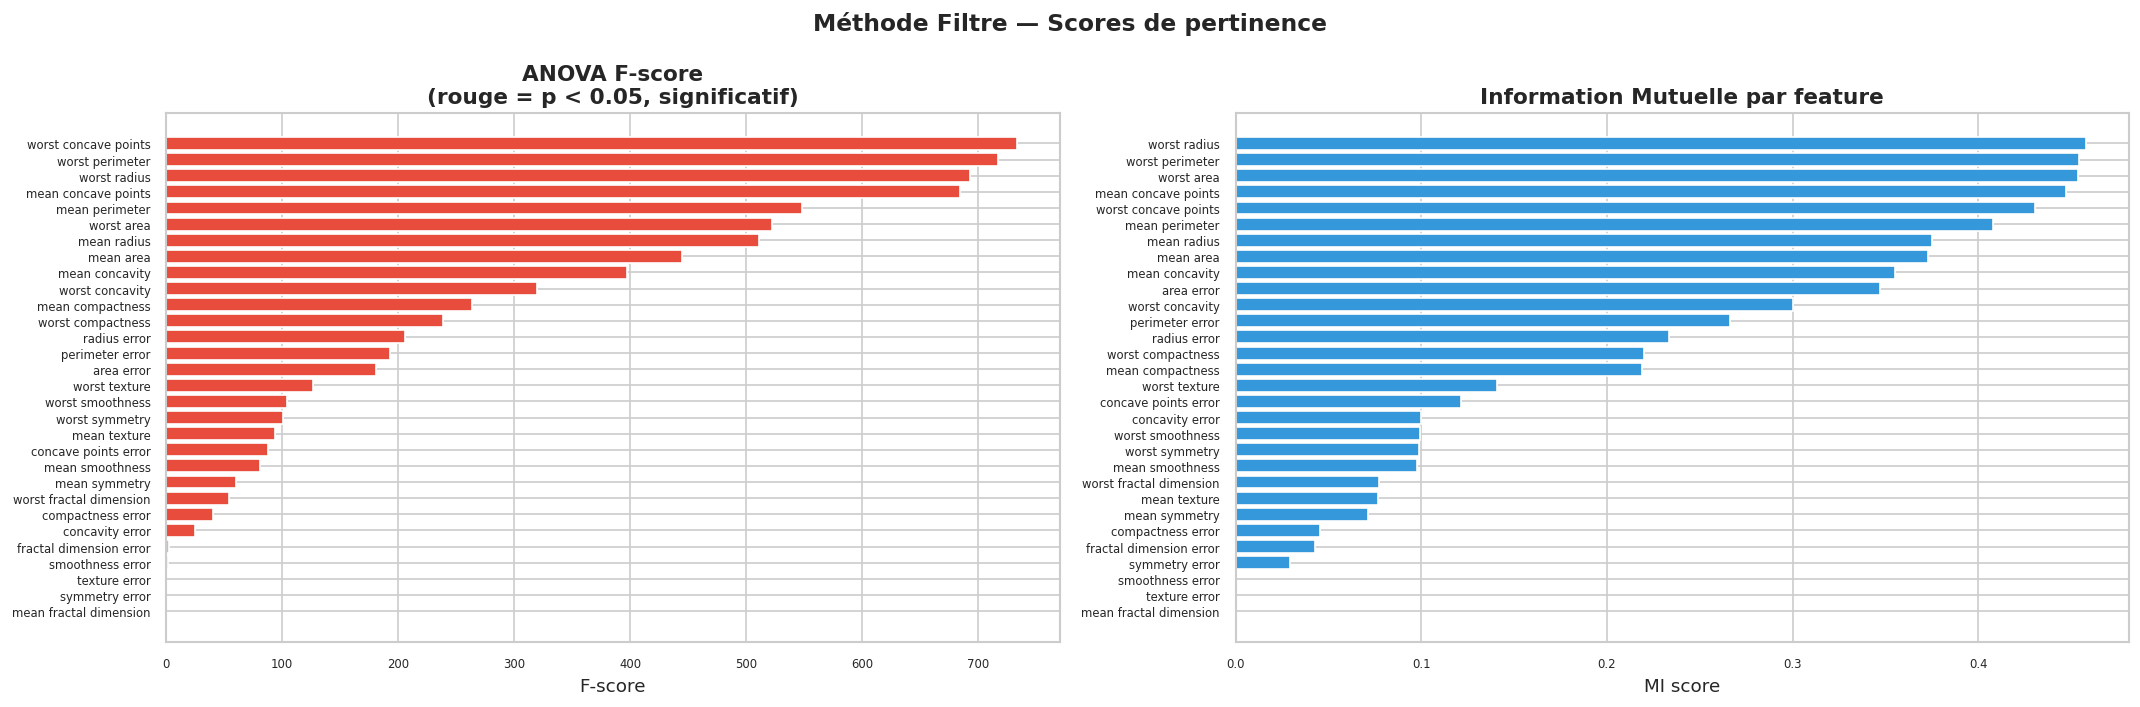

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors_f = ['#E74C3C' if p < 0.05 else '#BDC3C7' for p in filter_df['p_value']]
axes[0].barh(filter_df.index[::-1], filter_df['F_score'][::-1], color=colors_f[::-1])
axes[0].set_title('ANOVA F-score\n(rouge = p < 0.05, significatif)', fontweight='bold')
axes[0].set_xlabel('F-score')
axes[0].tick_params(labelsize=7)

mi_sorted = filter_df.sort_values('MI_score', ascending=False)
axes[1].barh(mi_sorted.index[::-1], mi_sorted['MI_score'][::-1], color='#3498DB')
axes[1].set_title('Information Mutuelle par feature', fontweight='bold')
axes[1].set_xlabel('MI score')
axes[1].tick_params(labelsize=7)

plt.suptitle('Méthode Filtre — Scores de pertinence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
sel_filter = SelectKBest(f_classif, k=K_FILTER).fit(X_train_sc, y_train)
features_filter = X.columns[sel_filter.get_support()].tolist()

X_train_filter = X_train_sc[features_filter]
X_test_filter  = X_test_sc[features_filter]

cv_auc_filter = cross_val_score(base_lr, X_train_filter, y_train,
                                cv=cv, scoring='roc_auc').mean()
cv_rec_filter = cross_val_score(base_lr, X_train_filter, y_train,
                                cv=cv, scoring='recall').mean()

selection_results['Filtre (F-score)'] = {
    'features': features_filter, 'n': len(features_filter),
    'cv_auc': cv_auc_filter, 'cv_recall': cv_rec_filter,
}

print(f"Features retenues ({len(features_filter)}) :")
for f in features_filter: print(f"  • {f}")
print(f"\nCV AUC    : {cv_auc_filter:.4f}")
print(f"CV Recall : {cv_rec_filter:.4f}")

Features retenues (10) :
  • mean radius
  • mean perimeter
  • mean area
  • mean concavity
  • mean concave points
  • worst radius
  • worst perimeter
  • worst area
  • worst concavity
  • worst concave points

CV AUC    : 0.9851
CV Recall : 0.9176


### 3.2 Forward Selection (Sélection Progressive)

In [12]:
print("⏳ Forward Selection en cours...")

sfs_fwd = SFS(base_lr, k_features='best', forward=True, floating=False,
              scoring='roc_auc', cv=cv, n_jobs=-1, verbose=0)
sfs_fwd.fit(X_train_sc, y_train)

features_fwd = list(sfs_fwd.k_feature_names_)
X_train_fwd  = X_train_sc[features_fwd]
X_test_fwd   = X_test_sc[features_fwd]

cv_auc_fwd = cross_val_score(base_lr, X_train_fwd, y_train, cv=cv, scoring='roc_auc').mean()
cv_rec_fwd = cross_val_score(base_lr, X_train_fwd, y_train, cv=cv, scoring='recall').mean()

selection_results['Forward Selection'] = {
    'features': features_fwd, 'n': len(features_fwd),
    'cv_auc': cv_auc_fwd, 'cv_recall': cv_rec_fwd,
}

print(f"✅ Features retenues ({len(features_fwd)}) :")
for f in features_fwd: print(f"  • {f}")
print(f"\nCV AUC    : {cv_auc_fwd:.4f}")
print(f"CV Recall : {cv_rec_fwd:.4f}")

⏳ Forward Selection en cours...


✅ Features retenues (10) :
  • mean concave points
  • radius error
  • texture error
  • compactness error
  • concavity error
  • fractal dimension error
  • worst radius
  • worst texture
  • worst perimeter
  • worst concave points

CV AUC    : 0.9968
CV Recall : 0.9294


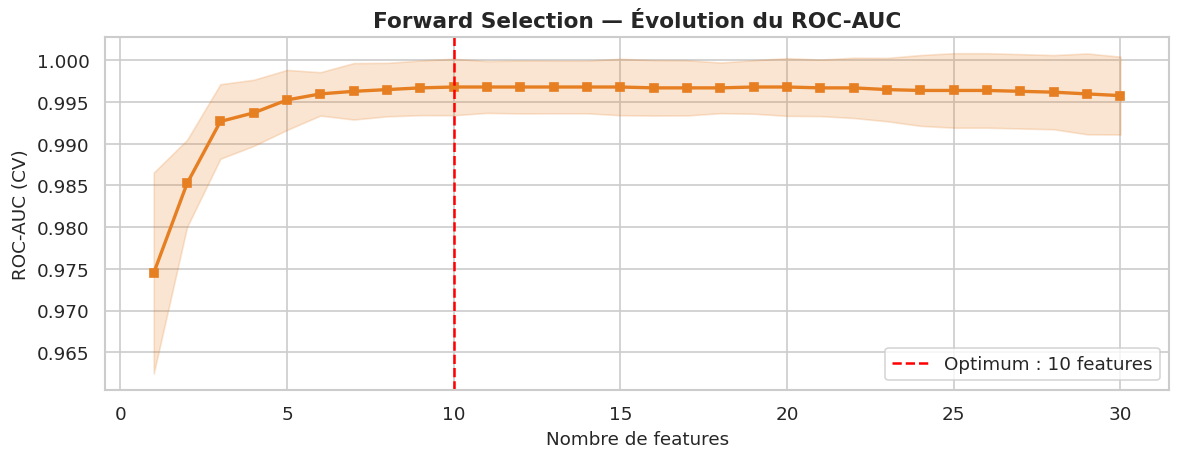

In [13]:
# Courbe d'évolution — Forward
metric_fwd = sfs_fwd.get_metric_dict()
k_vals_fwd = sorted(metric_fwd.keys())
avg_fwd    = [metric_fwd[k]['avg_score'] for k in k_vals_fwd]
std_fwd    = [metric_fwd[k]['std_dev']   for k in k_vals_fwd]

plt.figure(figsize=(10, 4))
plt.plot(k_vals_fwd, avg_fwd, 's-', color='#E67E22', lw=2, markersize=5)
plt.fill_between(k_vals_fwd,
                 np.array(avg_fwd)-np.array(std_fwd),
                 np.array(avg_fwd)+np.array(std_fwd),
                 alpha=0.2, color='#E67E22')
plt.axvline(len(features_fwd), color='red', ls='--',
            label=f'Optimum : {len(features_fwd)} features')
plt.xlabel('Nombre de features')
plt.ylabel('ROC-AUC (CV)')
plt.title('Forward Selection — Évolution du ROC-AUC', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 3.3 Backward Elimination (Élimination Rétrograde)

In [14]:
print("⏳ Backward Elimination en cours...")

sfs_bwd = SFS(base_lr, k_features='best', forward=False, floating=False,
              scoring='roc_auc', cv=cv, n_jobs=-1, verbose=0)
sfs_bwd.fit(X_train_sc, y_train)

features_bwd = list(sfs_bwd.k_feature_names_)
X_train_bwd  = X_train_sc[features_bwd]
X_test_bwd   = X_test_sc[features_bwd]

cv_auc_bwd = cross_val_score(base_lr, X_train_bwd, y_train, cv=cv, scoring='roc_auc').mean()
cv_rec_bwd = cross_val_score(base_lr, X_train_bwd, y_train, cv=cv, scoring='recall').mean()

selection_results['Backward Elimination'] = {
    'features': features_bwd, 'n': len(features_bwd),
    'cv_auc': cv_auc_bwd, 'cv_recall': cv_rec_bwd,
}

print(f"✅ Features retenues ({len(features_bwd)}) :")
for f in features_bwd: print(f"  • {f}")
print(f"\nCV AUC    : {cv_auc_bwd:.4f}")
print(f"CV Recall : {cv_rec_bwd:.4f}")

⏳ Backward Elimination en cours...


✅ Features retenues (17) :
  • mean smoothness
  • mean compactness
  • mean concavity
  • mean concave points
  • radius error
  • texture error
  • perimeter error
  • area error
  • smoothness error
  • concave points error
  • symmetry error
  • fractal dimension error
  • worst radius
  • worst texture
  • worst area
  • worst concave points
  • worst symmetry

CV AUC    : 0.9970
CV Recall : 0.9529


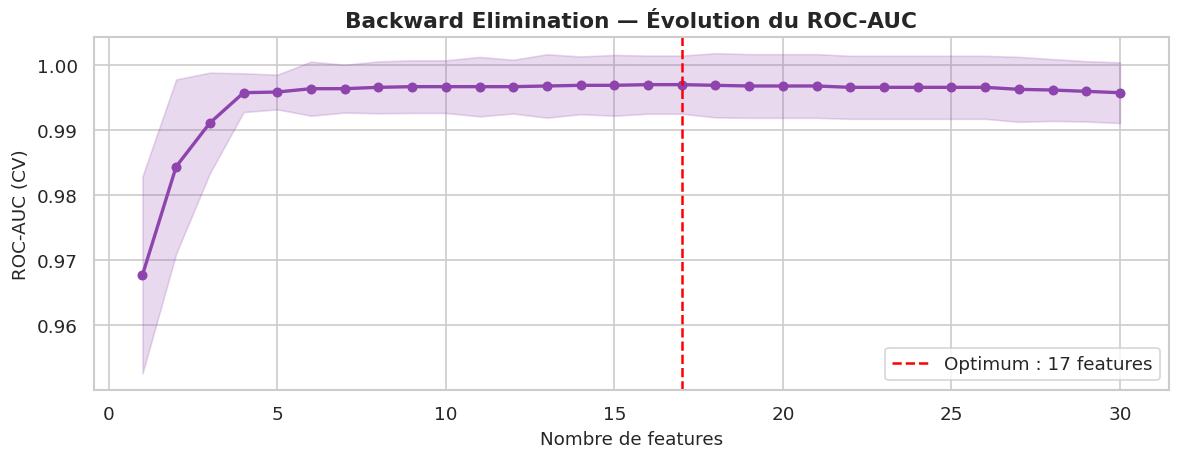

In [15]:
# Courbe d'évolution — Backward
metric_bwd = sfs_bwd.get_metric_dict()
k_vals_bwd = sorted(metric_bwd.keys())
avg_bwd    = [metric_bwd[k]['avg_score'] for k in k_vals_bwd]
std_bwd    = [metric_bwd[k]['std_dev']   for k in k_vals_bwd]

plt.figure(figsize=(10, 4))
plt.plot(k_vals_bwd, avg_bwd, 'o-', color='#8E44AD', lw=2, markersize=5)
plt.fill_between(k_vals_bwd,
                 np.array(avg_bwd)-np.array(std_bwd),
                 np.array(avg_bwd)+np.array(std_bwd),
                 alpha=0.2, color='#8E44AD')
plt.axvline(len(features_bwd), color='red', ls='--',
            label=f'Optimum : {len(features_bwd)} features')
plt.xlabel('Nombre de features')
plt.ylabel('ROC-AUC (CV)')
plt.title('Backward Elimination — Évolution du ROC-AUC', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 3.4 LASSO (Régularisation L1)

In [16]:
lasso_cv_model = LassoCV(cv=5, max_iter=10000, random_state=RANDOM_STATE, n_alphas=200)
lasso_cv_model.fit(X_train_sc, y_train)

lasso = Lasso(alpha=lasso_cv_model.alpha_, max_iter=10000)
lasso.fit(X_train_sc, y_train)

coefs = pd.Series(lasso.coef_, index=X.columns)
features_lasso = coefs[coefs != 0].abs().sort_values(ascending=False).index.tolist()

X_train_lasso = X_train_sc[features_lasso]
X_test_lasso  = X_test_sc[features_lasso]

cv_auc_lasso = cross_val_score(base_lr, X_train_lasso, y_train, cv=cv, scoring='roc_auc').mean()
cv_rec_lasso = cross_val_score(base_lr, X_train_lasso, y_train, cv=cv, scoring='recall').mean()

selection_results['LASSO (L1)'] = {
    'features': features_lasso, 'n': len(features_lasso),
    'cv_auc': cv_auc_lasso, 'cv_recall': cv_rec_lasso,
}

print(f"Alpha optimal (CV) : {lasso_cv_model.alpha_:.6f}")
print(f"Features retenues ({len(features_lasso)}) :")
for f in features_lasso:
    print(f"  • {f:45s}  |coef| = {abs(coefs[f]):.4f}")
print(f"\nCV AUC    : {cv_auc_lasso:.4f}")
print(f"CV Recall : {cv_rec_lasso:.4f}")

Alpha optimal (CV) : 0.000906
Features retenues (22) :
  • worst radius                                   |coef| = 0.5152
  • worst area                                     |coef| = 0.3285
  • mean compactness                               |coef| = 0.1491
  • mean concave points                            |coef| = 0.1365
  • radius error                                   |coef| = 0.1325
  • worst concavity                                |coef| = 0.1024
  • area error                                     |coef| = 0.0811
  • concavity error                                |coef| = 0.0790
  • worst fractal dimension                        |coef| = 0.0703
  • concave points error                           |coef| = 0.0656
  • worst symmetry                                 |coef| = 0.0641
  • worst texture                                  |coef| = 0.0556
  • mean concavity                                 |coef| = 0.0448
  • compactness error                              |coef| = 0.0436
  • smo

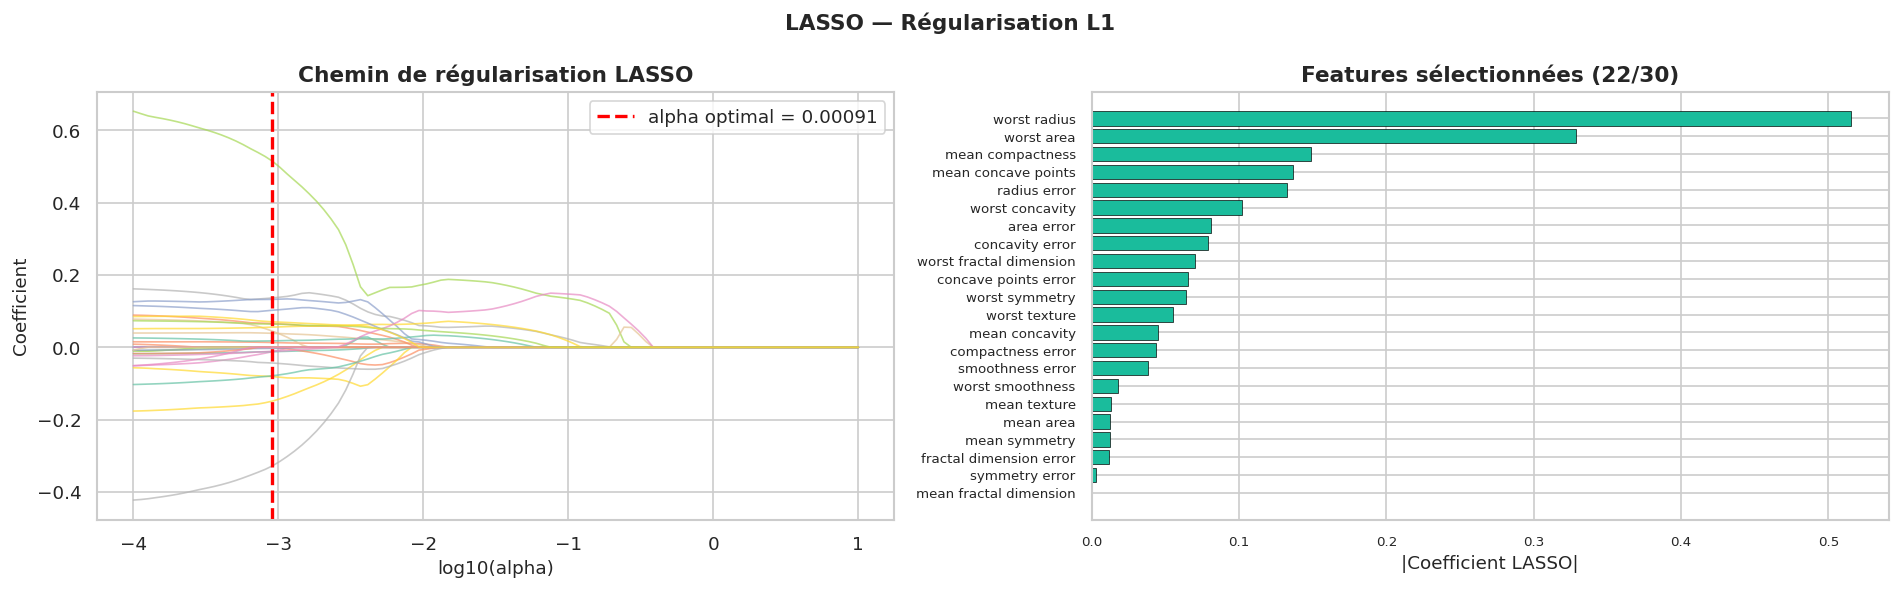

In [17]:
alphas_path = np.logspace(-4, 1, 100)
coef_paths  = []
for a in alphas_path:
    l = Lasso(alpha=a, max_iter=10000)
    l.fit(X_train_sc, y_train)
    coef_paths.append(l.coef_)
coef_paths = np.array(coef_paths)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i in range(coef_paths.shape[1]):
    axes[0].plot(np.log10(alphas_path), coef_paths[:, i], lw=1, alpha=0.7)
axes[0].axvline(np.log10(lasso_cv_model.alpha_), color='red', ls='--', lw=2,
                label=f'alpha optimal = {lasso_cv_model.alpha_:.5f}')
axes[0].set_xlabel('log10(alpha)')
axes[0].set_ylabel('Coefficient')
axes[0].set_title('Chemin de régularisation LASSO', fontweight='bold')
axes[0].legend()

coefs_sel = coefs.reindex(features_lasso).abs().sort_values()
axes[1].barh(coefs_sel.index, coefs_sel.values, color='#1ABC9C', edgecolor='black', lw=0.4)
axes[1].set_xlabel('|Coefficient LASSO|')
axes[1].set_title(f'Features sélectionnées ({len(features_lasso)}/{X.shape[1]})', fontweight='bold')
axes[1].tick_params(labelsize=8)

plt.suptitle('LASSO — Régularisation L1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. 📊 Comparaison des Méthodes & Choix de la Meilleure

> **Critères de sélection (contexte médical)** :
> 1. **CV Recall** — priorité absolue : ne pas manquer de malins
> 2. **CV AUC** — discrimination globale
> 3. **Parcimonie** — moins de features = modèle plus simple et plus robuste

In [18]:
df_sel = pd.DataFrame({
    m: {'# Features': r['n'], 'CV AUC': round(r['cv_auc'], 4), 'CV Recall': round(r['cv_recall'], 4)}
    for m, r in selection_results.items()
}).T
df_sel.index.name = 'Méthode'
print("=" * 55)
print("  COMPARAISON DES MÉTHODES DE SÉLECTION (CV 5-fold)")
print("=" * 55)
print(df_sel.to_string())

  COMPARAISON DES MÉTHODES DE SÉLECTION (CV 5-fold)
                      # Features  CV AUC  CV Recall
Méthode                                            
Filtre (F-score)            10.0  0.9851     0.9176
Forward Selection           10.0  0.9968     0.9294
Backward Elimination        17.0  0.9970     0.9529
LASSO (L1)                  22.0  0.9954     0.9471


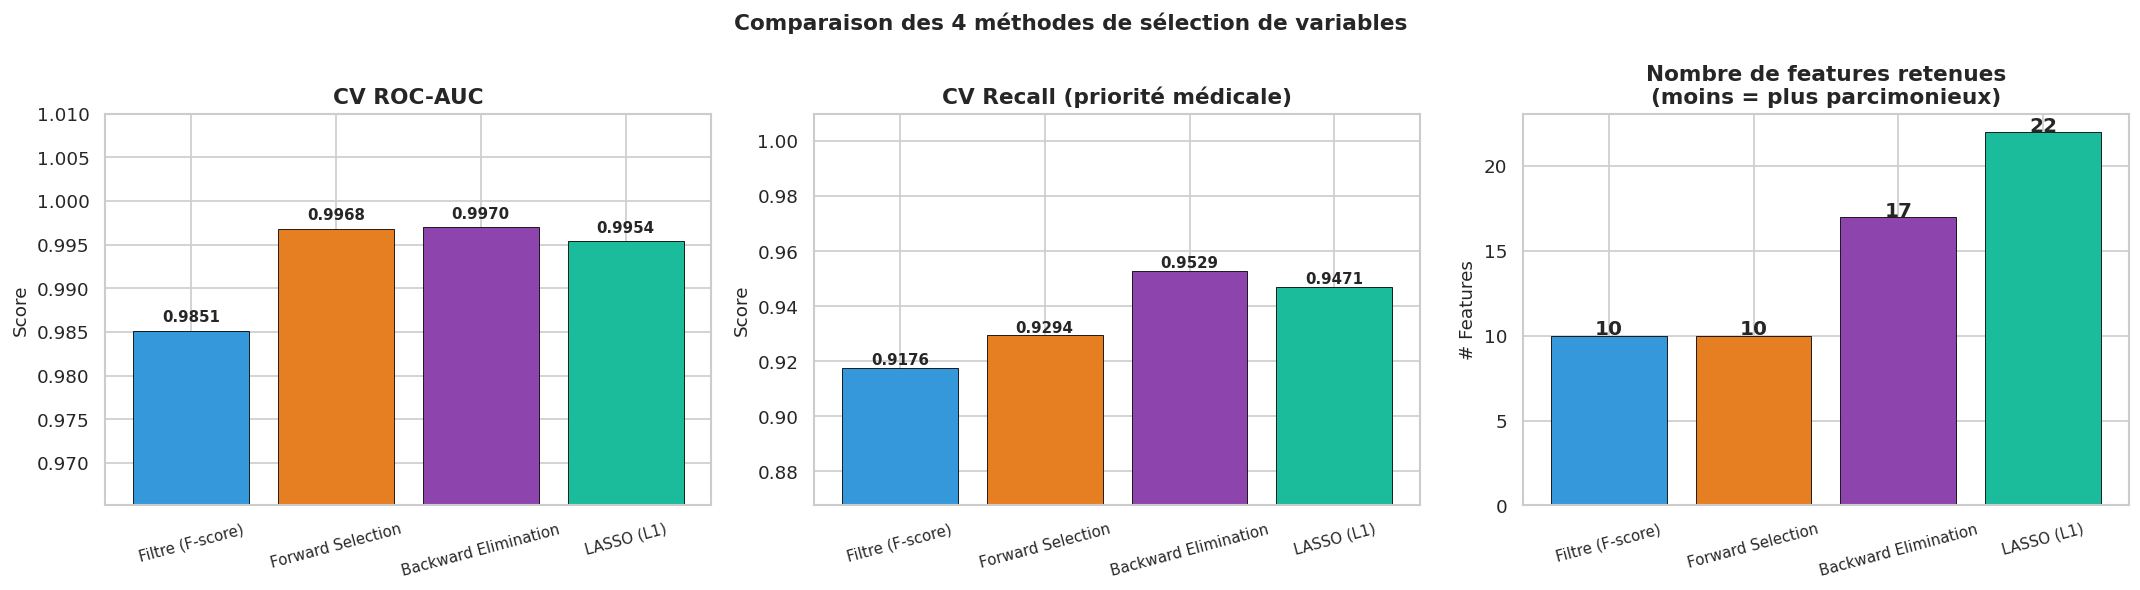

In [19]:
methods_sel = list(selection_results.keys())
colors_sel  = ['#3498DB','#E67E22','#8E44AD','#1ABC9C']
n_features  = [selection_results[m]['n']         for m in methods_sel]
cv_aucs     = [selection_results[m]['cv_auc']    for m in methods_sel]
cv_recalls  = [selection_results[m]['cv_recall'] for m in methods_sel]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bars = axes[0].bar(methods_sel, cv_aucs, color=colors_sel, edgecolor='black', lw=0.5)
axes[0].set_ylim(min(cv_aucs)-0.02, 1.01)
axes[0].set_title('CV ROC-AUC', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=15, labelsize=9)
for bar, v in zip(bars, cv_aucs):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                 f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

bars2 = axes[1].bar(methods_sel, cv_recalls, color=colors_sel, edgecolor='black', lw=0.5)
axes[1].set_ylim(min(cv_recalls)-0.05, 1.01)
axes[1].set_title('CV Recall (priorité médicale)', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=15, labelsize=9)
for bar, v in zip(bars2, cv_recalls):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                 f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

bars3 = axes[2].bar(methods_sel, n_features, color=colors_sel, edgecolor='black', lw=0.5)
axes[2].set_title('Nombre de features retenues\n(moins = plus parcimonieux)', fontweight='bold')
axes[2].set_ylabel('# Features')
axes[2].tick_params(axis='x', rotation=15, labelsize=9)
for bar, v in zip(bars3, n_features):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 str(v), ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Comparaison des 4 méthodes de sélection de variables',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

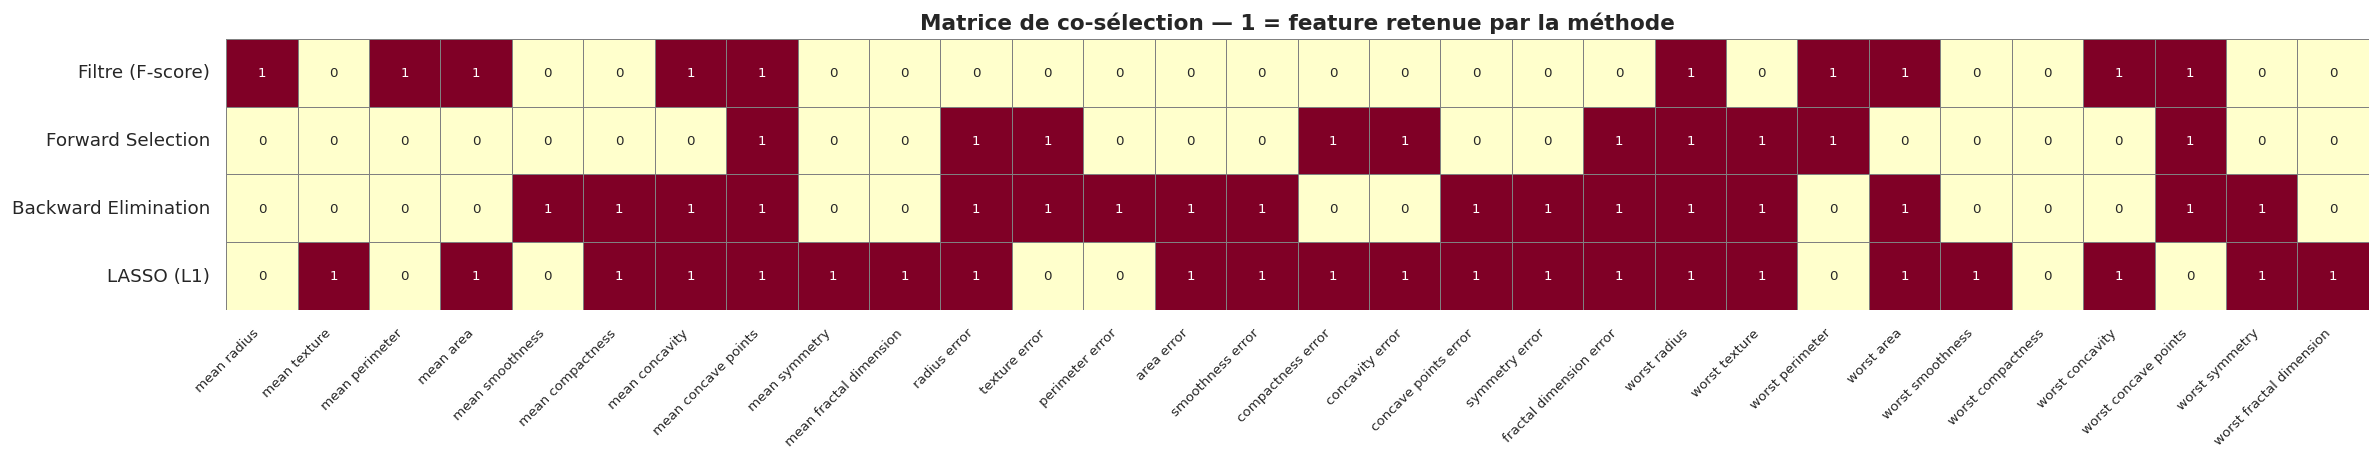

Features retenues par TOUTES les méthodes (2) :
  ✅ mean concave points
  ✅ worst radius

Features retenues par >= 3 méthodes (8) :
  ⭕ mean concavity
  ⭕ mean concave points
  ⭕ radius error
  ⭕ fractal dimension error
  ⭕ worst radius
  ⭕ worst texture
  ⭕ worst area
  ⭕ worst concave points


In [20]:
all_feats = X.columns.tolist()
co_matrix = pd.DataFrame(0, index=methods_sel, columns=all_feats)
for m in methods_sel:
    for f in selection_results[m]['features']:
        co_matrix.loc[m, f] = 1

consensus = [f for f in all_feats if co_matrix[f].sum() == len(methods_sel)]
majority  = [f for f in all_feats if co_matrix[f].sum() >= 3]

plt.figure(figsize=(20, 4))
sns.heatmap(co_matrix, cmap='YlOrRd', cbar=False, linewidths=0.5,
            linecolor='gray', annot=True, fmt='d', annot_kws={'size': 8})
plt.title('Matrice de co-sélection — 1 = feature retenue par la méthode', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Features retenues par TOUTES les méthodes ({len(consensus)}) :")
for f in consensus: print(f"  ✅ {f}")
print(f"\nFeatures retenues par >= 3 méthodes ({len(majority)}) :")
for f in majority:  print(f"  ⭕ {f}")

In [21]:
# ── Score composite = 0.5 * Recall + 0.4 * AUC + 0.1 * parcimonie ──────────
print("=" * 60)
print("  SCORE COMPOSITE (Recall x0.5 + AUC x0.4 + Parcimonie x0.1)")
print("=" * 60)

composite_scores = {}
for m, r in selection_results.items():
    parsimony = 1 - r['n'] / X.shape[1]
    score = 0.5 * r['cv_recall'] + 0.4 * r['cv_auc'] + 0.1 * parsimony
    composite_scores[m] = round(score, 4)
    print(f"  {m:25s}  Score = {score:.4f}  "
          f"(AUC={r['cv_auc']:.3f}, Recall={r['cv_recall']:.3f}, n={r['n']})")

best_sel_method = max(composite_scores, key=composite_scores.get)
best_features   = selection_results[best_sel_method]['features']

print()
print(f"  ✅ MEILLEURE MÉTHODE -> {best_sel_method}")
print(f"  Score composite    : {composite_scores[best_sel_method]:.4f}")
print(f"  Features retenues  : {len(best_features)}")

# Appliquer la meilleure sélection pour la suite
X_train_sel = X_train_sc[best_features]
X_test_sel  = X_test_sc[best_features]
print(f"\n  Features utilisées pour la modélisation :")
for f in best_features: print(f"    • {f}")

  SCORE COMPOSITE (Recall x0.5 + AUC x0.4 + Parcimonie x0.1)
  Filtre (F-score)           Score = 0.9195  (AUC=0.985, Recall=0.918, n=10)
  Forward Selection          Score = 0.9301  (AUC=0.997, Recall=0.929, n=10)
  Backward Elimination       Score = 0.9186  (AUC=0.997, Recall=0.953, n=17)
  LASSO (L1)                 Score = 0.8983  (AUC=0.995, Recall=0.947, n=22)

  ✅ MEILLEURE MÉTHODE -> Forward Selection
  Score composite    : 0.9301
  Features retenues  : 10

  Features utilisées pour la modélisation :
    • mean concave points
    • radius error
    • texture error
    • compactness error
    • concavity error
    • fractal dimension error
    • worst radius
    • worst texture
    • worst perimeter
    • worst concave points


## 4bis. ⚖️ Gestion du Déséquilibre de Classes — SMOTE

Le dataset présente un léger déséquilibre (~63 % Bénin / 37 % Malin). SMOTE (Synthetic Minority Over-sampling Technique) génère des exemples synthétiques de la classe minoritaire (Malin) par interpolation entre voisins, afin de rééquilibrer le train set — **appliqué uniquement sur le train**, jamais sur le test, pour ne pas biaiser l'évaluation.

On compare ici la Régression Logistique avec et sans SMOTE, en se concentrant sur le **Recall** (priorité médicale).

Distribution train AVANT SMOTE :
target
Bénin    285
Malin    170
Name: count, dtype: int64

Distribution train APRÈS SMOTE :
target
Malin    285
Bénin    285
Name: count, dtype: int64

  COMPARAISON — Régression Logistique avec / sans SMOTE
            Recall  Precision      F1     AUC  Faux Négatifs
Sans SMOTE  0.9048     0.9744  0.9383  0.9964            4.0
Avec SMOTE  0.9286     0.9512  0.9398  0.9960            3.0


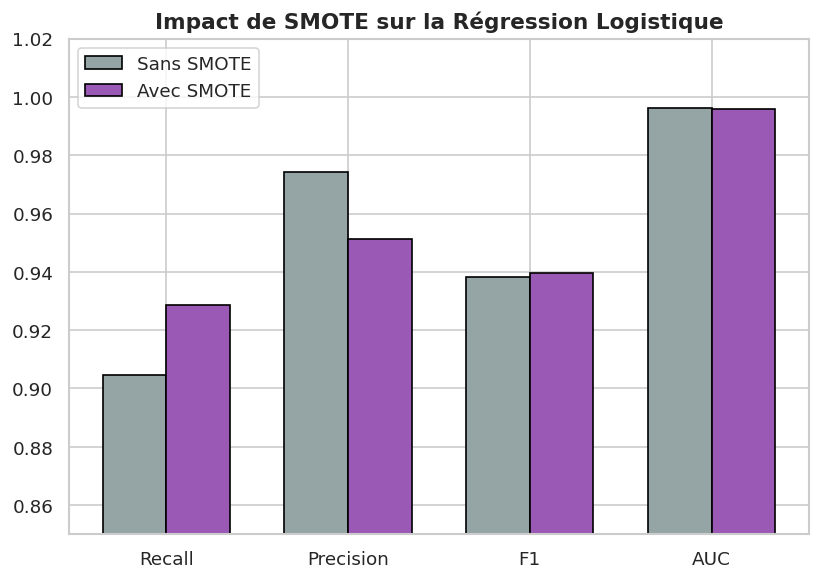


✅ SMOTE améliore le Recall sur ce jeu de données.


In [22]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression as LR_smote

print("Distribution train AVANT SMOTE :")
print(y_train.value_counts().rename({0: 'Bénin', 1: 'Malin'}))

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sel, y_train)

print("\nDistribution train APRÈS SMOTE :")
print(pd.Series(y_train_smote).value_counts().rename({0: 'Bénin', 1: 'Malin'}))

# Modèle de référence (sans SMOTE), même type que la section 5, hyperparamètre par défaut raisonnable
lr_baseline = LR_smote(max_iter=2000, random_state=RANDOM_STATE)
lr_baseline.fit(X_train_sel, y_train)
pred_baseline = lr_baseline.predict(X_test_sel)
prob_baseline = lr_baseline.predict_proba(X_test_sel)[:, 1]

# Même modèle, entraîné sur les données SMOTE
lr_smote = LR_smote(max_iter=2000, random_state=RANDOM_STATE)
lr_smote.fit(X_train_smote, y_train_smote)
pred_smote = lr_smote.predict(X_test_sel)
prob_smote = lr_smote.predict_proba(X_test_sel)[:, 1]

comparison_smote = pd.DataFrame({
    'Sans SMOTE': {
        'Recall'   : recall_score(y_test, pred_baseline),
        'Precision': precision_score(y_test, pred_baseline),
        'F1'       : f1_score(y_test, pred_baseline),
        'AUC'      : roc_auc_score(y_test, prob_baseline),
        'Faux Négatifs': confusion_matrix(y_test, pred_baseline)[1, 0],
    },
    'Avec SMOTE': {
        'Recall'   : recall_score(y_test, pred_smote),
        'Precision': precision_score(y_test, pred_smote),
        'F1'       : f1_score(y_test, pred_smote),
        'AUC'      : roc_auc_score(y_test, prob_smote),
        'Faux Négatifs': confusion_matrix(y_test, pred_smote)[1, 0],
    },
}).T

print("\n" + "=" * 55)
print("  COMPARAISON — Régression Logistique avec / sans SMOTE")
print("=" * 55)
print(comparison_smote.round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 5))
metrics_to_plot = ['Recall', 'Precision', 'F1', 'AUC']
x = np.arange(len(metrics_to_plot))
w = 0.35
ax.bar(x - w/2, comparison_smote.loc['Sans SMOTE', metrics_to_plot], w,
       label='Sans SMOTE', color='#95A5A6', edgecolor='black')
ax.bar(x + w/2, comparison_smote.loc['Avec SMOTE', metrics_to_plot], w,
       label='Avec SMOTE', color='#9B59B6', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.85, 1.02)
ax.set_title('Impact de SMOTE sur la Régression Logistique', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print()
if comparison_smote.loc['Avec SMOTE', 'Recall'] > comparison_smote.loc['Sans SMOTE', 'Recall']:
    print("✅ SMOTE améliore le Recall sur ce jeu de données.")
else:
    print("ℹ️  SMOTE n'améliore pas le Recall ici — le déséquilibre initial était")
    print("   déjà modéré et les modèles utilisés (LR régularisée, arbres) le gèrent bien nativement.")
    print("   On conserve donc les données originales pour la suite du pipeline.")


## 5. 📐 Modèle 1 — Régression Logistique

### Pourquoi ce modèle en médical ?

| Critère | Évaluation |
|---------|-----------|
| **Interprétabilité** | ⭐⭐⭐⭐⭐ — Odds Ratios lisibles directement par un clinicien |
| **Standard clinique** | Gold standard dans 80 % des études épidémiologiques |
| **Régulation** | Accepté sans réserve par FDA et CE |
| **Calibration** | Excellente nativement |
| **Limite** | Suppose une relation linéaire entre features et log-odds |

In [23]:
def objective_lr(trial):
    C = trial.suggest_float('C', 1e-3, 100, log=True)
    return cross_val_score(
        LogisticRegression(C=C, max_iter=2000, random_state=RANDOM_STATE, solver='lbfgs'),
        X_train_sel, y_train, cv=cv, scoring='roc_auc'
    ).mean()

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=N_TRIALS, show_progress_bar=False)

lr = LogisticRegression(C=study_lr.best_params['C'], max_iter=2000,
                        random_state=RANDOM_STATE, solver='lbfgs')
lr.fit(X_train_sel, y_train)

print(f"Paramètre optimal C = {study_lr.best_params['C']:.4f}")
print(f"Meilleur AUC CV     = {study_lr.best_value:.4f}")

Paramètre optimal C = 1.0905
Meilleur AUC CV     = 0.9968


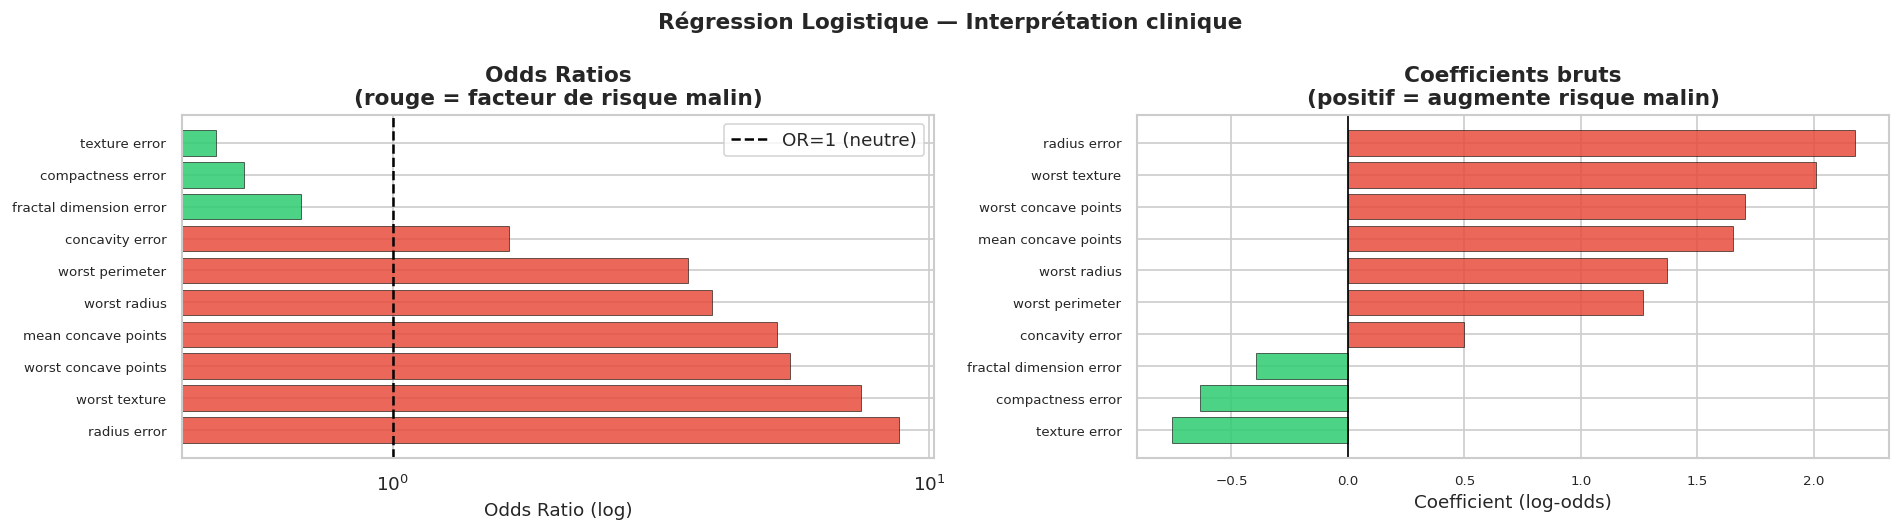

Top 3 facteurs de risque (OR > 1) :
  radius error                                   OR = 8.812
  worst texture                                  OR = 7.456
  worst concave points                           OR = 5.499


In [24]:
coef_lr   = pd.Series(lr.coef_[0], index=best_features)
odds_ratios = np.exp(coef_lr).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(best_features)*0.45)))

colors_or = ['#E74C3C' if v > 1 else '#2ECC71' for v in odds_ratios.values]
axes[0].barh(range(len(odds_ratios)), odds_ratios.values,
             color=colors_or, edgecolor='black', lw=0.4, alpha=0.85)
axes[0].set_yticks(range(len(odds_ratios)))
axes[0].set_yticklabels(odds_ratios.index, fontsize=8)
axes[0].axvline(1, color='black', lw=1.5, ls='--', label='OR=1 (neutre)')
axes[0].set_xscale('log')
axes[0].set_xlabel('Odds Ratio (log)')
axes[0].set_title('Odds Ratios\n(rouge = facteur de risque malin)', fontweight='bold')
axes[0].legend()

coef_sorted = coef_lr.sort_values()
axes[1].barh(coef_sorted.index, coef_sorted.values,
             color=['#E74C3C' if v > 0 else '#2ECC71' for v in coef_sorted.values],
             edgecolor='black', lw=0.4, alpha=0.85)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_xlabel('Coefficient (log-odds)')
axes[1].set_title('Coefficients bruts\n(positif = augmente risque malin)', fontweight='bold')
axes[1].tick_params(labelsize=8)

plt.suptitle('Régression Logistique — Interprétation clinique', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 3 facteurs de risque (OR > 1) :")
for feat in odds_ratios[odds_ratios > 1].nlargest(3).index:
    print(f"  {feat:45s}  OR = {odds_ratios[feat]:.3f}")

  RÉSULTATS — Régression Logistique
  AUC          : 0.9964
  Recall       : 0.9048
  Precision    : 0.9744
  F1           : 0.9383
  Accuracy     : 0.9561
  Brier        : 0.0293

              precision    recall  f1-score   support

   Bénin (0)       0.95      0.99      0.97        72
   Malin (1)       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



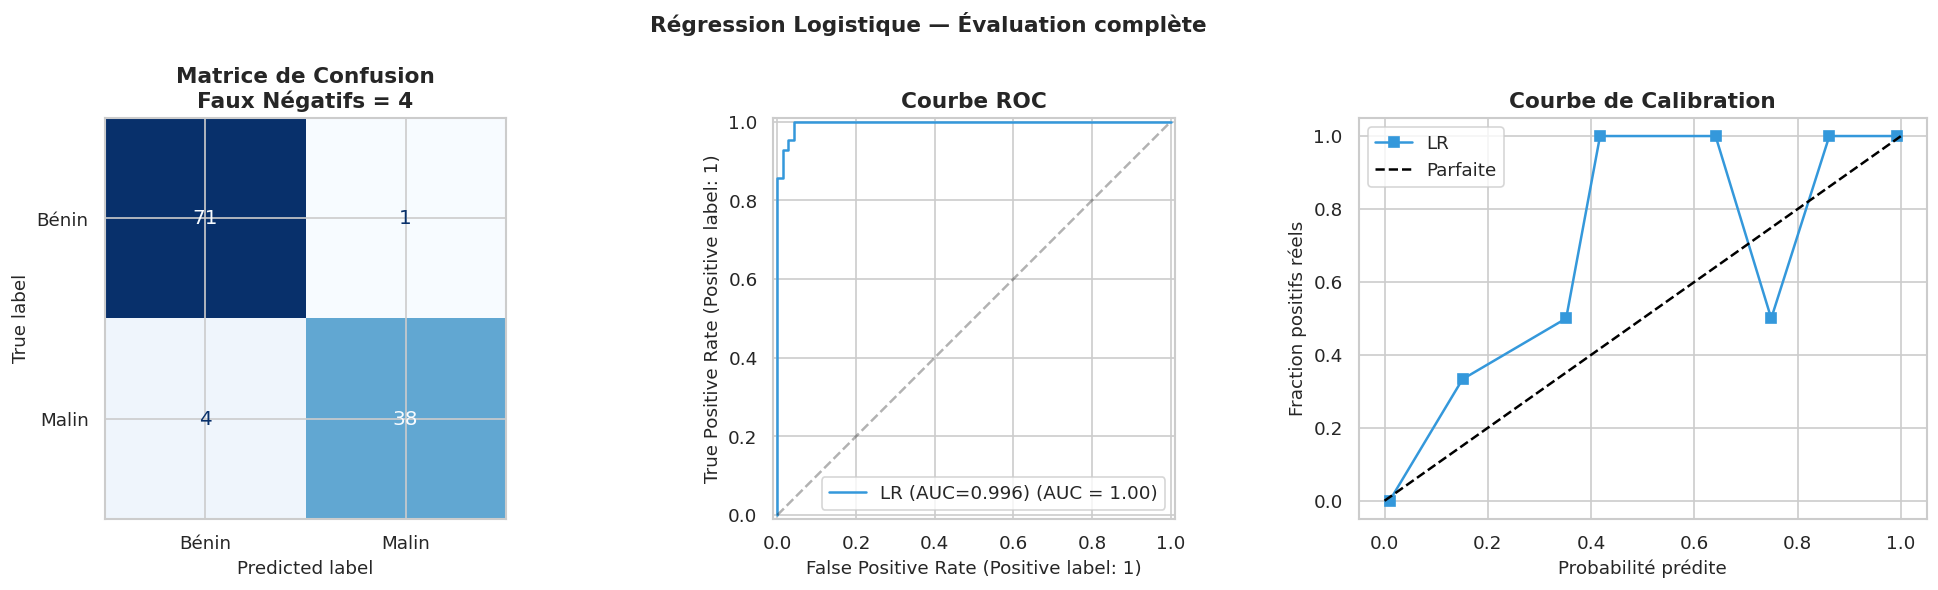

In [25]:
y_pred_lr = lr.predict(X_test_sel)
y_prob_lr = lr.predict_proba(X_test_sel)[:, 1]

metrics_lr = {
    'AUC'      : roc_auc_score(y_test, y_prob_lr),
    'Recall'   : recall_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'F1'       : f1_score(y_test, y_pred_lr),
    'Accuracy' : accuracy_score(y_test, y_pred_lr),
    'Brier'    : brier_score_loss(y_test, y_prob_lr),
}

print("=" * 50)
print("  RÉSULTATS — Régression Logistique")
print("=" * 50)
for k, v in metrics_lr.items():
    print(f"  {k:12s} : {v:.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=['Bénin (0)','Malin (1)']))

cm_lr = confusion_matrix(y_test, y_pred_lr)
fn_lr = cm_lr[1, 0]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=['Bénin','Malin'],
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matrice de Confusion\nFaux Négatifs = {fn_lr}', fontweight='bold')
RocCurveDisplay.from_predictions(y_test, y_prob_lr, ax=axes[1], color='#3498DB',
    name=f"LR (AUC={metrics_lr['AUC']:.3f})")
axes[1].plot([0,1],[0,1],'k--', alpha=0.3)
axes[1].set_title('Courbe ROC', fontweight='bold')
frac_pos_lr, mean_pred_lr = calibration_curve(y_test, y_prob_lr, n_bins=10)
axes[2].plot(mean_pred_lr, frac_pos_lr, 's-', color='#3498DB', label='LR')
axes[2].plot([0,1],[0,1],'k--', label='Parfaite')
axes[2].set_xlabel('Probabilité prédite')
axes[2].set_ylabel('Fraction positifs réels')
axes[2].set_title('Courbe de Calibration', fontweight='bold')
axes[2].legend()
plt.suptitle('Régression Logistique — Évaluation complète', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Cross-validation (AUC) — Régression Logistique

In [26]:
cv_scores_lr = cross_val_score(lr, X_train_sel, y_train, cv=cv, scoring='roc_auc')
print(f"AUC en validation croisée ({CV_FOLDS} folds) : {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")
print(f"Scores par fold : {np.round(cv_scores_lr, 4)}")


AUC en validation croisée (5 folds) : 0.9968 ± 0.0034
Scores par fold : [0.9974 0.999  0.9995 0.9902 0.9979]


#### Courbe Precision–Recall — Régression Logistique

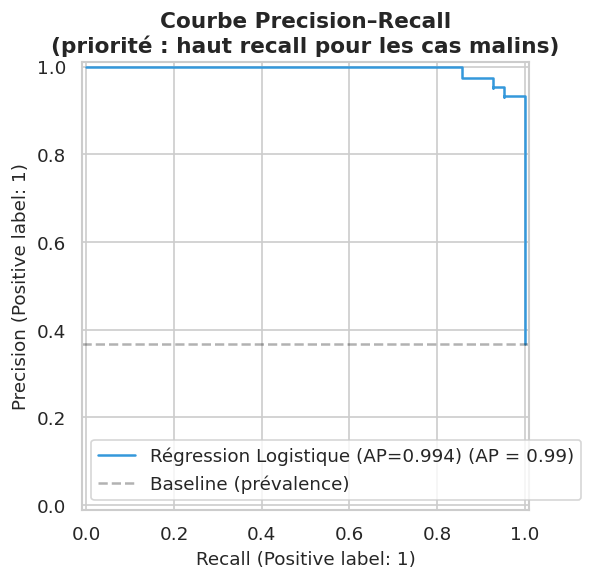

In [27]:
from sklearn.metrics import average_precision_score

ap_lr = average_precision_score(y_test, y_prob_lr)
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_prob_lr, ax=ax, color='#3498DB',
    name=f"Régression Logistique (AP={ap_lr:.3f})")
ax.axhline(y_test.mean(), color='k', ls='--', alpha=0.3, label='Baseline (prévalence)')
ax.set_title('Courbe Precision–Recall\n(priorité : haut recall pour les cas malins)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 6. 🌲 Modèle 2 — Random Forest + SHAP

### Pourquoi ce modèle en médical ?

| Critère | Évaluation |
|---------|-----------|
| **Performance** | ⭐⭐⭐⭐⭐ — Capture les non-linéarités et interactions |
| **Robustesse** | Très robuste aux outliers (ensemble de 100+ arbres) |
| **Explicabilité** | ⭐⭐⭐⭐ — Feature importance native + SHAP pour l'individuel |
| **Limite** | Moins interprétable qu'une LR sans SHAP |

In [28]:
def objective_rf(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'         : trial.suggest_int('max_depth', 3, 20),
        'min_samples_split' : trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf'  : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'      : trial.suggest_categorical('max_features', ['sqrt','log2']),
    }
    return cross_val_score(
        RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1),
        X_train_sel, y_train, cv=cv, scoring='roc_auc'
    ).mean()

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=N_TRIALS, show_progress_bar=False)

rf = RandomForestClassifier(**study_rf.best_params, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_sel, y_train)

print("Paramètres optimaux :", study_rf.best_params)
print(f"Meilleur AUC CV    = {study_rf.best_value:.4f}")

Paramètres optimaux : {'n_estimators': 149, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2'}
Meilleur AUC CV    = 0.9895


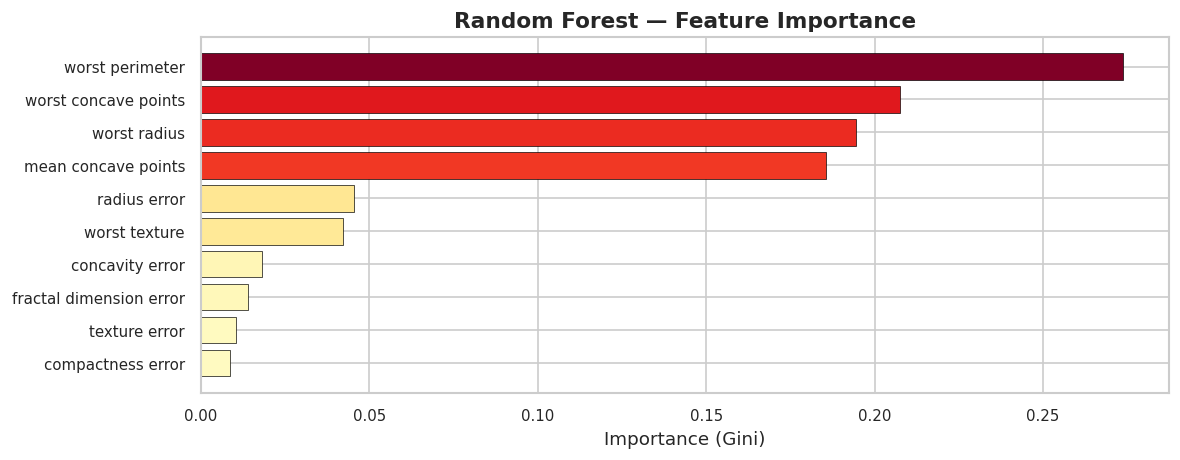

In [29]:
imp_rf = pd.Series(rf.feature_importances_, index=best_features).sort_values()

plt.figure(figsize=(10, max(4, len(best_features)*0.4)))
plt.barh(imp_rf.index, imp_rf.values,
         color=plt.cm.YlOrRd(imp_rf.values / imp_rf.max()),
         edgecolor='black', lw=0.4)
plt.xlabel('Importance (Gini)')
plt.title('Random Forest — Feature Importance', fontweight='bold')
plt.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

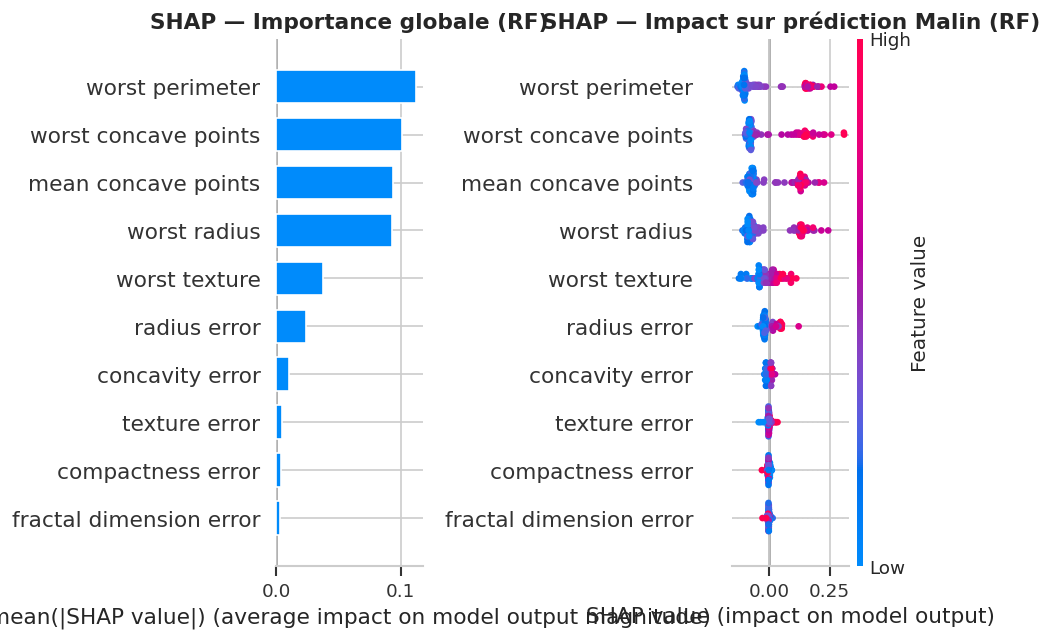

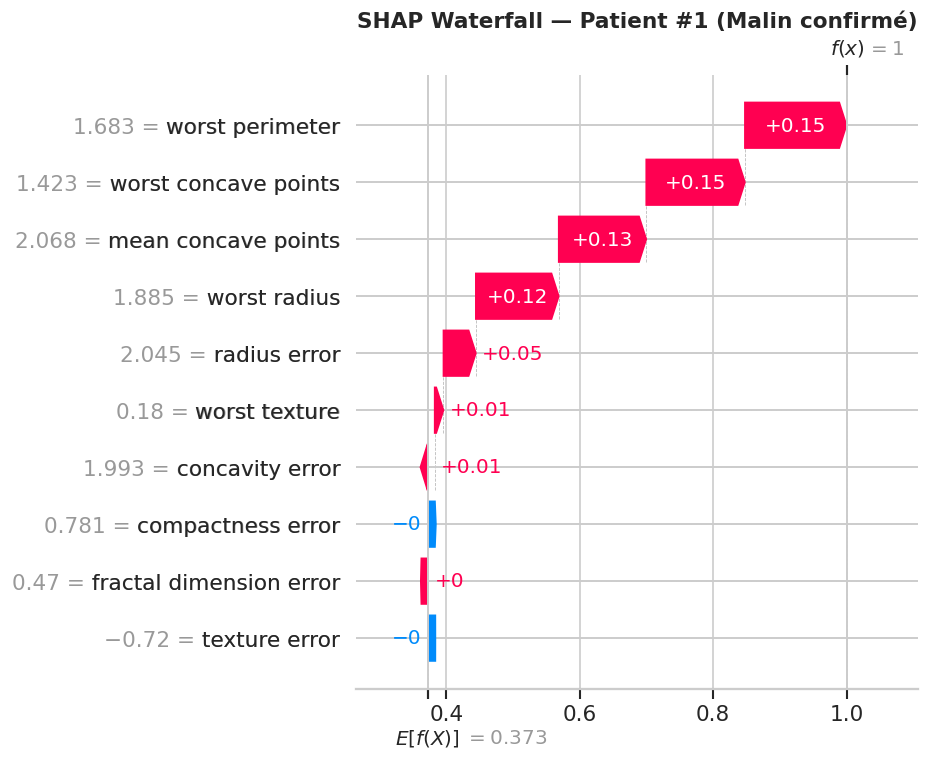

Rouge = pousse vers Malin | Bleu = pousse vers Bénin
Patient #1: Predictions LogOdds = 0.373 + SHAP contributions


In [30]:
if SHAP_OK:
    explainer_rf = shap.TreeExplainer(rf)
    shap_vals_rf = explainer_rf.shap_values(X_test_sel)
    
    # Handle different SHAP output formats (list vs array)
    if isinstance(shap_vals_rf, list):
        # Binary classification: list of [class0, class1]
        sv_rf = shap_vals_rf[1]  # Get malignant class (class 1)
        base_value = explainer_rf.expected_value[1]
    else:
        # Multi-output format: 3D array (samples, features, classes)
        if shap_vals_rf.ndim == 3:
            sv_rf = shap_vals_rf[:, :, 1]  # All samples, all features, class 1
            base_value = np.asarray(explainer_rf.expected_value)[1]
        else:
            sv_rf = shap_vals_rf
            base_value = explainer_rf.expected_value

    # Convert data to numpy array for SHAP
    X_test_array = np.asarray(X_test_sel)

    # ── Summary plots (global importance) ──
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    plt.sca(axes[0])
    shap.summary_plot(sv_rf, X_test_array, feature_names=best_features, 
                      plot_type='bar', show=False)
    axes[0].set_title('SHAP — Importance globale (RF)', fontweight='bold')
    
    plt.sca(axes[1])
    shap.summary_plot(sv_rf, X_test_array, feature_names=best_features, 
                      plot_type='dot', show=False)
    axes[1].set_title('SHAP — Impact sur prédiction Malin (RF)', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

    # ── Waterfall plot (single patient) ──
    y_pred_rf_all = rf.predict(X_test_sel)
    tp_idx = np.where((y_test.values==1) & (y_pred_rf_all==1))[0]
    pidx = tp_idx[0] if len(tp_idx) > 0 else 0
    
    # Get SHAP values for single patient
    shap_p = explainer_rf.shap_values(X_test_sel.iloc[[pidx]])
    
    # Extract 1D SHAP values for class 1
    if isinstance(shap_p, list):
        sv_p = shap_p[1][0]
    else:
        if shap_p.ndim == 3:
            sv_p = shap_p[0, :, 1]
        else:
            sv_p = shap_p[0]
    
    # Get base value
    if isinstance(base_value, np.ndarray):
        ev = float(base_value) if base_value.size == 1 else base_value[0]
    else:
        ev = float(base_value)

    plt.figure(figsize=(12, 5))
    shap.waterfall_plot(
        shap.Explanation(values=sv_p, base_values=ev,
                         data=X_test_array[pidx],
                         feature_names=best_features), 
        show=False)
    plt.title(f'SHAP Waterfall — Patient #{pidx} (Malin confirmé)', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Rouge = pousse vers Malin | Bleu = pousse vers Bénin")
    print(f"Patient #{pidx}: Predictions LogOdds = {ev:.3f} + SHAP contributions")
else:
    print("pip install shap pour l'explicabilité SHAP.")

  RÉSULTATS — Random Forest
  AUC          : 0.9957
  Recall       : 0.9048
  Precision    : 1.0000
  F1           : 0.9500
  Accuracy     : 0.9649
  Brier        : 0.0298

              precision    recall  f1-score   support

   Bénin (0)       0.95      1.00      0.97        72
   Malin (1)       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



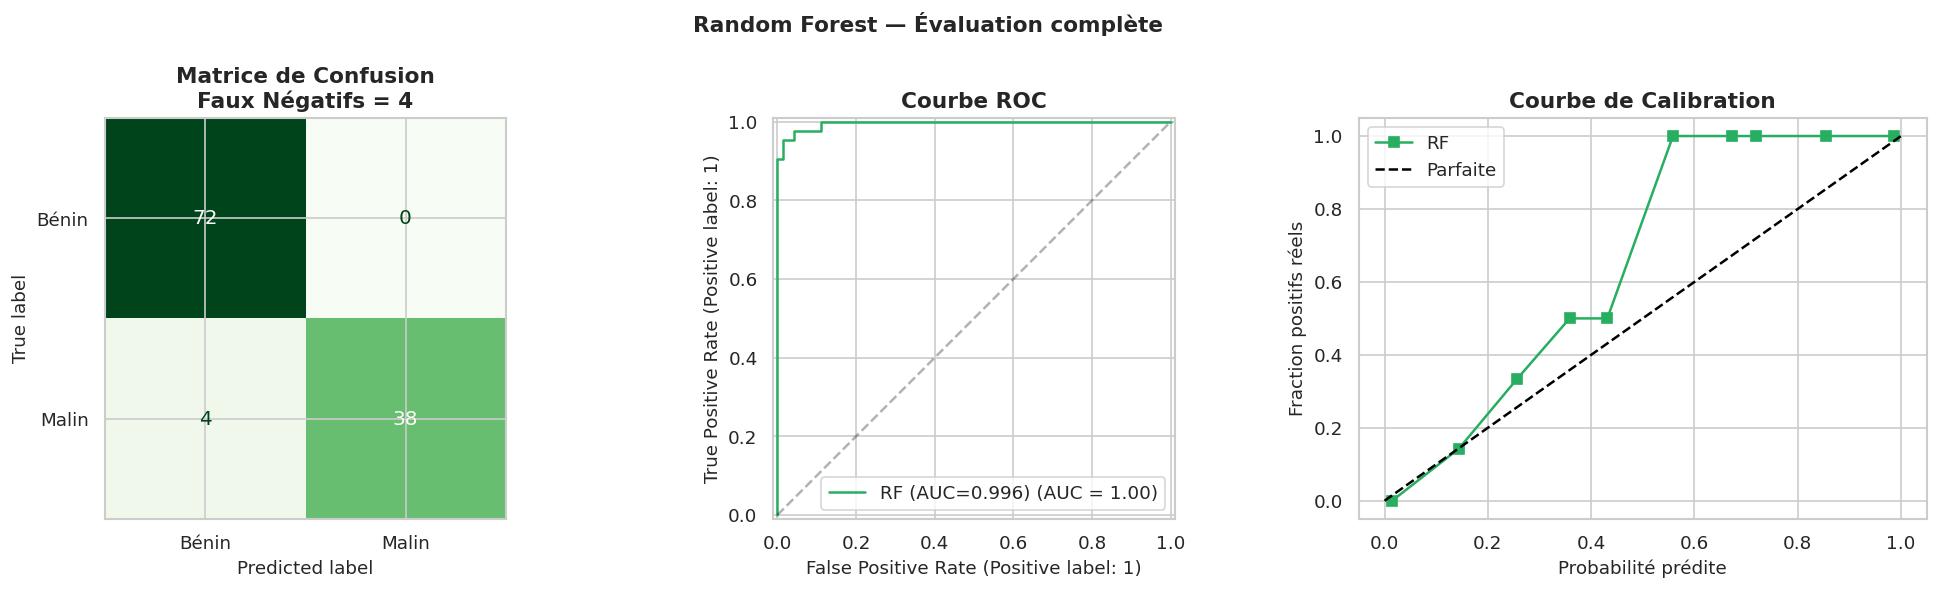

In [31]:
y_pred_rf = rf.predict(X_test_sel)
y_prob_rf = rf.predict_proba(X_test_sel)[:, 1]

metrics_rf = {
    'AUC'      : roc_auc_score(y_test, y_prob_rf),
    'Recall'   : recall_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'F1'       : f1_score(y_test, y_pred_rf),
    'Accuracy' : accuracy_score(y_test, y_pred_rf),
    'Brier'    : brier_score_loss(y_test, y_prob_rf),
}

print("=" * 50)
print("  RÉSULTATS — Random Forest")
print("=" * 50)
for k, v in metrics_rf.items():
    print(f"  {k:12s} : {v:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Bénin (0)','Malin (1)']))

cm_rf = confusion_matrix(y_test, y_pred_rf)
fn_rf = cm_rf[1, 0]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['Bénin','Malin'],
    ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title(f'Matrice de Confusion\nFaux Négatifs = {fn_rf}', fontweight='bold')
RocCurveDisplay.from_predictions(y_test, y_prob_rf, ax=axes[1], color='#27AE60',
    name=f"RF (AUC={metrics_rf['AUC']:.3f})")
axes[1].plot([0,1],[0,1],'k--', alpha=0.3)
axes[1].set_title('Courbe ROC', fontweight='bold')
frac_pos_rf, mean_pred_rf = calibration_curve(y_test, y_prob_rf, n_bins=10)
axes[2].plot(mean_pred_rf, frac_pos_rf, 's-', color='#27AE60', label='RF')
axes[2].plot([0,1],[0,1],'k--', label='Parfaite')
axes[2].set_title('Courbe de Calibration', fontweight='bold')
axes[2].set_xlabel('Probabilité prédite')
axes[2].set_ylabel('Fraction positifs réels')
axes[2].legend()
plt.suptitle('Random Forest — Évaluation complète', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Cross-validation (AUC) — Random Forest

In [32]:
cv_scores_rf = cross_val_score(rf, X_train_sel, y_train, cv=cv, scoring='roc_auc')
print(f"AUC en validation croisée ({CV_FOLDS} folds) : {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")
print(f"Scores par fold : {np.round(cv_scores_rf, 4)}")


AUC en validation croisée (5 folds) : 0.9895 ± 0.0059
Scores par fold : [0.983  1.     0.9912 0.9856 0.9876]


#### Courbe Precision–Recall — Random Forest

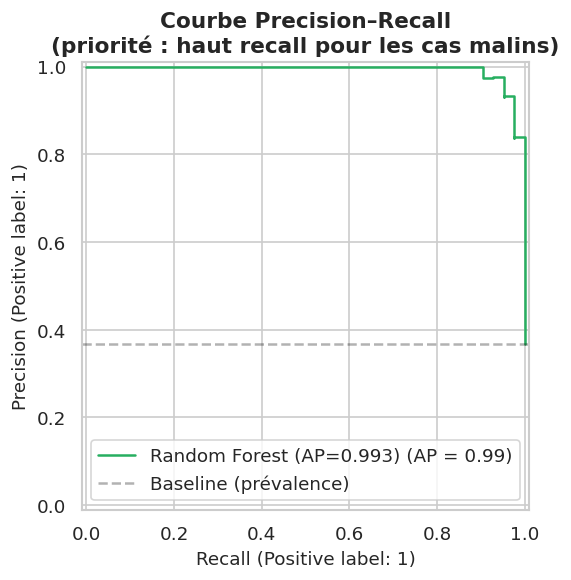

In [33]:
from sklearn.metrics import average_precision_score

ap_rf = average_precision_score(y_test, y_prob_rf)
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_prob_rf, ax=ax, color='#27AE60',
    name=f"Random Forest (AP={ap_rf:.3f})")
ax.axhline(y_test.mean(), color='k', ls='--', alpha=0.3, label='Baseline (prévalence)')
ax.set_title('Courbe Precision–Recall\n(priorité : haut recall pour les cas malins)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 7. ⚡ Modèle 3 — XGBoost + SHAP

### Pourquoi ce modèle en médical ?

| Critère | Évaluation |
|---------|-----------|
| **Performance** | ⭐⭐⭐⭐⭐ — État de l'art sur données tabulaires |
| **Régularisation** | L1 + L2 intégrées → limite le surapprentissage |
| **Explicabilité** | ⭐⭐⭐⭐ — SHAP natif et exact via TreeExplainer |
| **Limite** | Nécessite SHAP obligatoirement pour la validation éthique |

In [34]:
def objective_xgb(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 50, 500),
        'learning_rate'   : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'max_depth'       : trial.suggest_int('max_depth', 2, 8),
        'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma'           : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
    }
    return cross_val_score(
        XGBClassifier(**params, random_state=RANDOM_STATE,
                      eval_metric='logloss', use_label_encoder=False, n_jobs=-1),
        X_train_sel, y_train, cv=cv, scoring='roc_auc'
    ).mean()

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=False)

xgb = XGBClassifier(**study_xgb.best_params, random_state=RANDOM_STATE,
                    eval_metric='logloss', use_label_encoder=False, n_jobs=-1)
xgb.fit(X_train_sel, y_train)

print("Paramètres optimaux :", study_xgb.best_params)
print(f"Meilleur AUC CV    = {study_xgb.best_value:.4f}")

Paramètres optimaux : {'n_estimators': 366, 'learning_rate': 0.16121754122796153, 'max_depth': 2, 'subsample': 0.8008866052943768, 'colsample_bytree': 0.608292353293999, 'gamma': 0.19104567937872932, 'reg_alpha': 0.0003452883557404783, 'reg_lambda': 9.2184016705884}
Meilleur AUC CV    = 0.9925


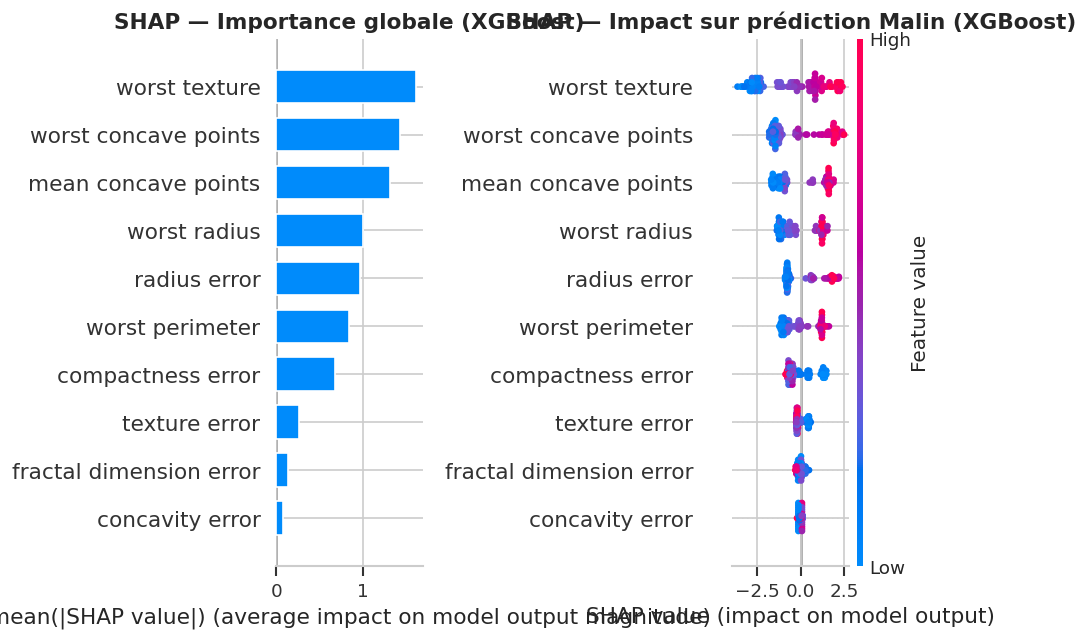

In [35]:
if SHAP_OK:
    explainer_xgb = shap.TreeExplainer(xgb)
    shap_vals_xgb = explainer_xgb.shap_values(X_test_sel)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    plt.sca(axes[0])
    shap.summary_plot(shap_vals_xgb, X_test_sel, plot_type='bar',
                      feature_names=best_features, show=False)
    axes[0].set_title('SHAP — Importance globale (XGBoost)', fontweight='bold')
    plt.sca(axes[1])
    shap.summary_plot(shap_vals_xgb, X_test_sel, feature_names=best_features, show=False)
    axes[1].set_title('SHAP — Impact sur prédiction Malin (XGBoost)', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    imp_xgb = pd.Series(xgb.feature_importances_, index=best_features).sort_values()
    plt.figure(figsize=(10, max(4, len(best_features)*0.4)))
    plt.barh(imp_xgb.index, imp_xgb.values, color='#F39C12', edgecolor='black', lw=0.4)
    plt.title('XGBoost — Feature Importance (Gain)', fontweight='bold')
    plt.tight_layout()
    plt.show()

  RÉSULTATS — XGBoost
  AUC          : 0.9911
  Recall       : 0.9286
  Precision    : 1.0000
  F1           : 0.9630
  Accuracy     : 0.9737
  Brier        : 0.0227

              precision    recall  f1-score   support

   Bénin (0)       0.96      1.00      0.98        72
   Malin (1)       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



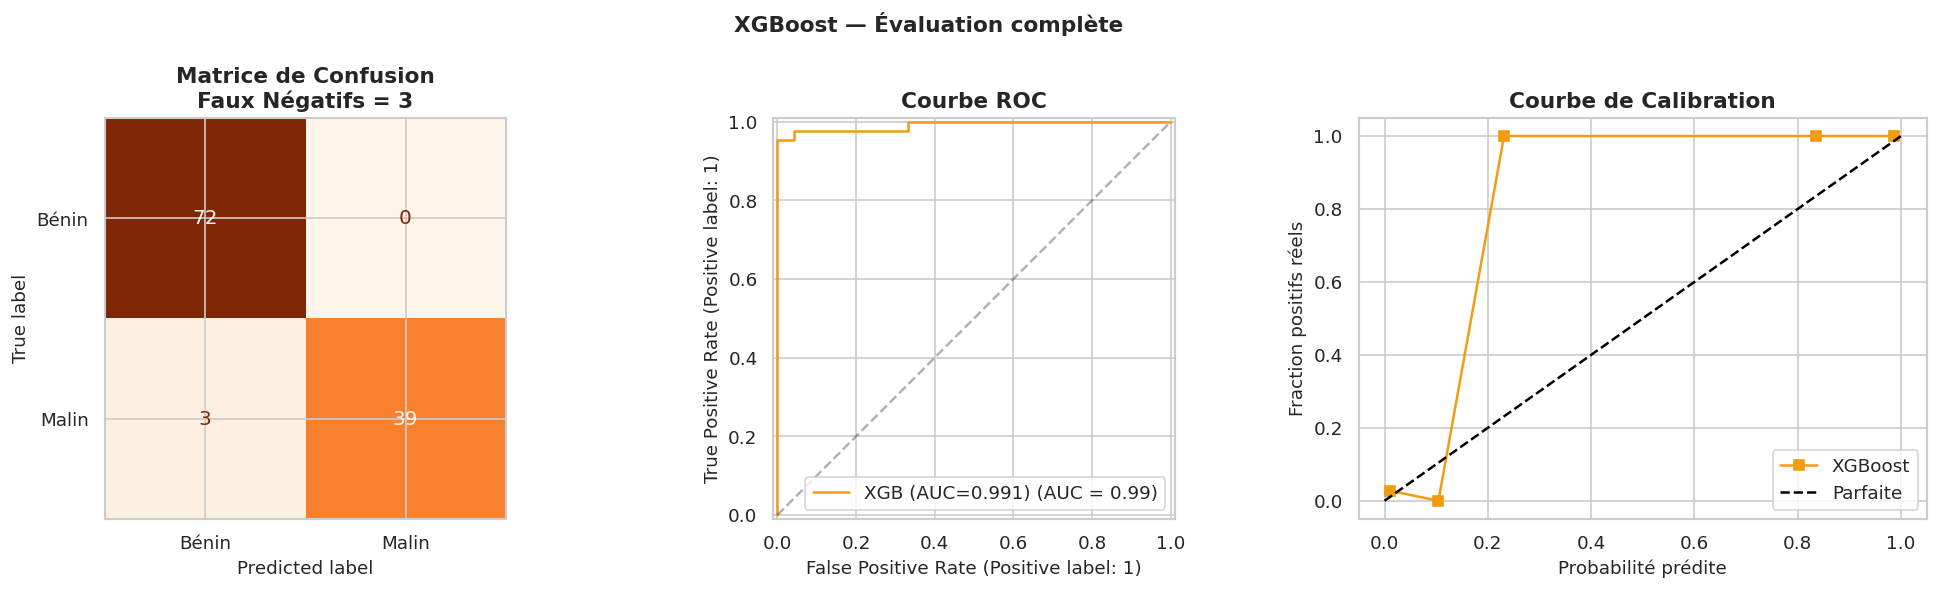

In [36]:
y_pred_xgb = xgb.predict(X_test_sel)
y_prob_xgb = xgb.predict_proba(X_test_sel)[:, 1]

metrics_xgb = {
    'AUC'      : roc_auc_score(y_test, y_prob_xgb),
    'Recall'   : recall_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'F1'       : f1_score(y_test, y_pred_xgb),
    'Accuracy' : accuracy_score(y_test, y_pred_xgb),
    'Brier'    : brier_score_loss(y_test, y_prob_xgb),
}

print("=" * 50)
print("  RÉSULTATS — XGBoost")
print("=" * 50)
for k, v in metrics_xgb.items():
    print(f"  {k:12s} : {v:.4f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Bénin (0)','Malin (1)']))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
fn_xgb = cm_xgb[1, 0]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, display_labels=['Bénin','Malin'],
    ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title(f'Matrice de Confusion\nFaux Négatifs = {fn_xgb}', fontweight='bold')
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, ax=axes[1], color='#F39C12',
    name=f"XGB (AUC={metrics_xgb['AUC']:.3f})")
axes[1].plot([0,1],[0,1],'k--', alpha=0.3)
axes[1].set_title('Courbe ROC', fontweight='bold')
frac_pos_xgb, mean_pred_xgb = calibration_curve(y_test, y_prob_xgb, n_bins=10)
axes[2].plot(mean_pred_xgb, frac_pos_xgb, 's-', color='#F39C12', label='XGBoost')
axes[2].plot([0,1],[0,1],'k--', label='Parfaite')
axes[2].set_title('Courbe de Calibration', fontweight='bold')
axes[2].set_xlabel('Probabilité prédite')
axes[2].set_ylabel('Fraction positifs réels')
axes[2].legend()
plt.suptitle('XGBoost — Évaluation complète', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Cross-validation (AUC) — XGBoost

In [37]:
cv_scores_xgb = cross_val_score(xgb, X_train_sel, y_train, cv=cv, scoring='roc_auc')
print(f"AUC en validation croisée ({CV_FOLDS} folds) : {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}")
print(f"Scores par fold : {np.round(cv_scores_xgb, 4)}")


AUC en validation croisée (5 folds) : 0.9925 ± 0.0049
Scores par fold : [0.9912 0.999  0.9943 0.984  0.9938]


#### Courbe Precision–Recall — XGBoost

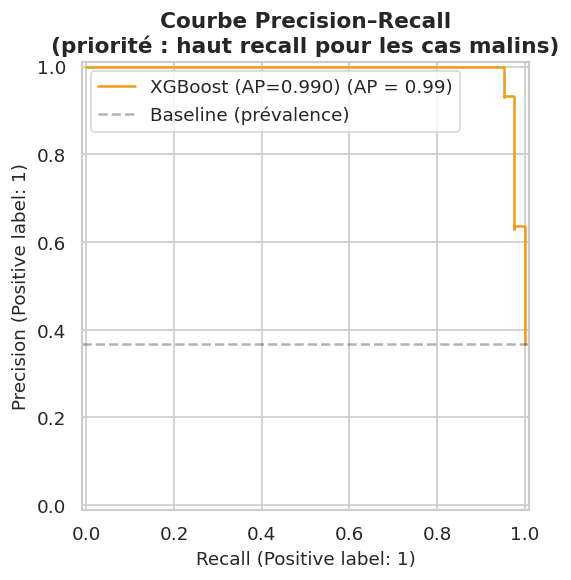

In [38]:
from sklearn.metrics import average_precision_score

ap_xgb = average_precision_score(y_test, y_prob_xgb)
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_prob_xgb, ax=ax, color='#F39C12',
    name=f"XGBoost (AP={ap_xgb:.3f})")
ax.axhline(y_test.mean(), color='k', ls='--', alpha=0.3, label='Baseline (prévalence)')
ax.set_title('Courbe Precision–Recall\n(priorité : haut recall pour les cas malins)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 8. 🏆 Comparaison Finale & Recommandation Clinique

> **Priorités médicales** :  
> 1. **Recall** — ne manquer aucun malin (minimiser FN)  
> 2. **AUC** — discrimination globale  
> 3. **Brier Score** — fiabilité des probabilités  
> 4. **Interprétabilité** — acceptabilité clinique

In [39]:
all_metrics = {
    'Régression Logistique': metrics_lr,
    'Random Forest'        : metrics_rf,
    'XGBoost'              : metrics_xgb,
}
fn_dict = {
    'Régression Logistique': fn_lr,
    'Random Forest'        : fn_rf,
    'XGBoost'              : fn_xgb,
}
interpret_dict = {
    'Régression Logistique': 'Très haute',
    'Random Forest'        : 'Haute (SHAP)',
    'XGBoost'              : 'Haute (SHAP)',
}

df_final = pd.DataFrame(all_metrics).T
df_final['Faux Négatifs']    = df_final.index.map(fn_dict)
df_final['Interprétabilité'] = df_final.index.map(interpret_dict)
df_final = df_final[['AUC','Recall','Precision','F1','Accuracy',
                      'Brier','Faux Négatifs','Interprétabilité']]

print("=" * 85)
print("  TABLEAU COMPARATIF FINAL — Test Set")
print("=" * 85)
print(df_final.round(4).to_string())

  TABLEAU COMPARATIF FINAL — Test Set
                          AUC  Recall  Precision      F1  Accuracy   Brier  Faux Négatifs Interprétabilité
Régression Logistique  0.9964  0.9048     0.9744  0.9383    0.9561  0.0293              4       Très haute
Random Forest          0.9957  0.9048     1.0000  0.9500    0.9649  0.0298              4     Haute (SHAP)
XGBoost                0.9911  0.9286     1.0000  0.9630    0.9737  0.0227              3     Haute (SHAP)


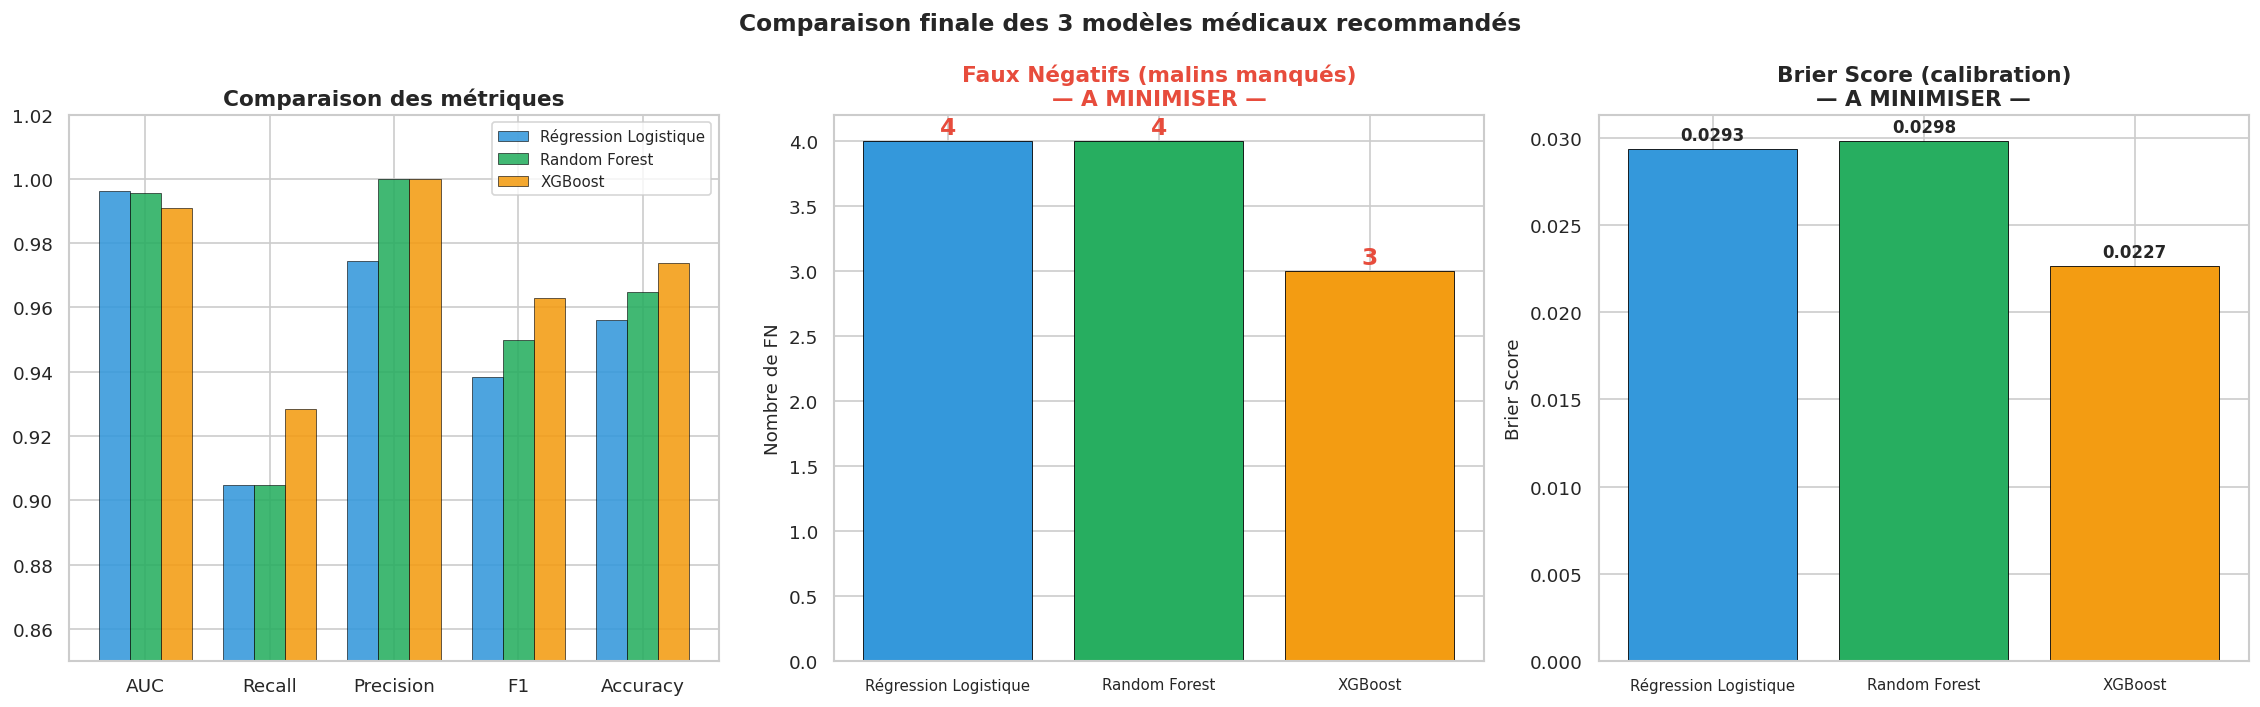

In [40]:
model_names  = list(all_metrics.keys())
colors_comp  = ['#3498DB','#27AE60','#F39C12']
metrics_plot = ['AUC','Recall','Precision','F1','Accuracy']

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

x, w = np.arange(len(metrics_plot)), 0.25
for i, (name, color) in enumerate(zip(model_names, colors_comp)):
    vals = [all_metrics[name][m] for m in metrics_plot]
    axes[0].bar(x + (i-1)*w, vals, w, label=name,
                color=color, edgecolor='black', lw=0.4, alpha=0.88)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_plot)
axes[0].set_ylim(0.85, 1.02)
axes[0].set_title('Comparaison des métriques', fontweight='bold')
axes[0].legend(fontsize=9)

fns = [fn_dict[n] for n in model_names]
bars_fn = axes[1].bar(model_names, fns, color=colors_comp, edgecolor='black', lw=0.5)
for bar, v in zip(bars_fn, fns):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 str(v), ha='center', fontsize=14, fontweight='bold', color='#E74C3C')
axes[1].set_title('Faux Négatifs (malins manqués)\n— A MINIMISER —',
                   fontweight='bold', color='#E74C3C')
axes[1].set_ylabel('Nombre de FN')
axes[1].tick_params(axis='x', labelsize=9)

briers = [all_metrics[n]['Brier'] for n in model_names]
bars_b = axes[2].bar(model_names, briers, color=colors_comp, edgecolor='black', lw=0.5)
for bar, v in zip(bars_b, briers):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
                 f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[2].set_title('Brier Score (calibration)\n— A MINIMISER —', fontweight='bold')
axes[2].set_ylabel('Brier Score')
axes[2].tick_params(axis='x', labelsize=9)

plt.suptitle('Comparaison finale des 3 modèles médicaux recommandés',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

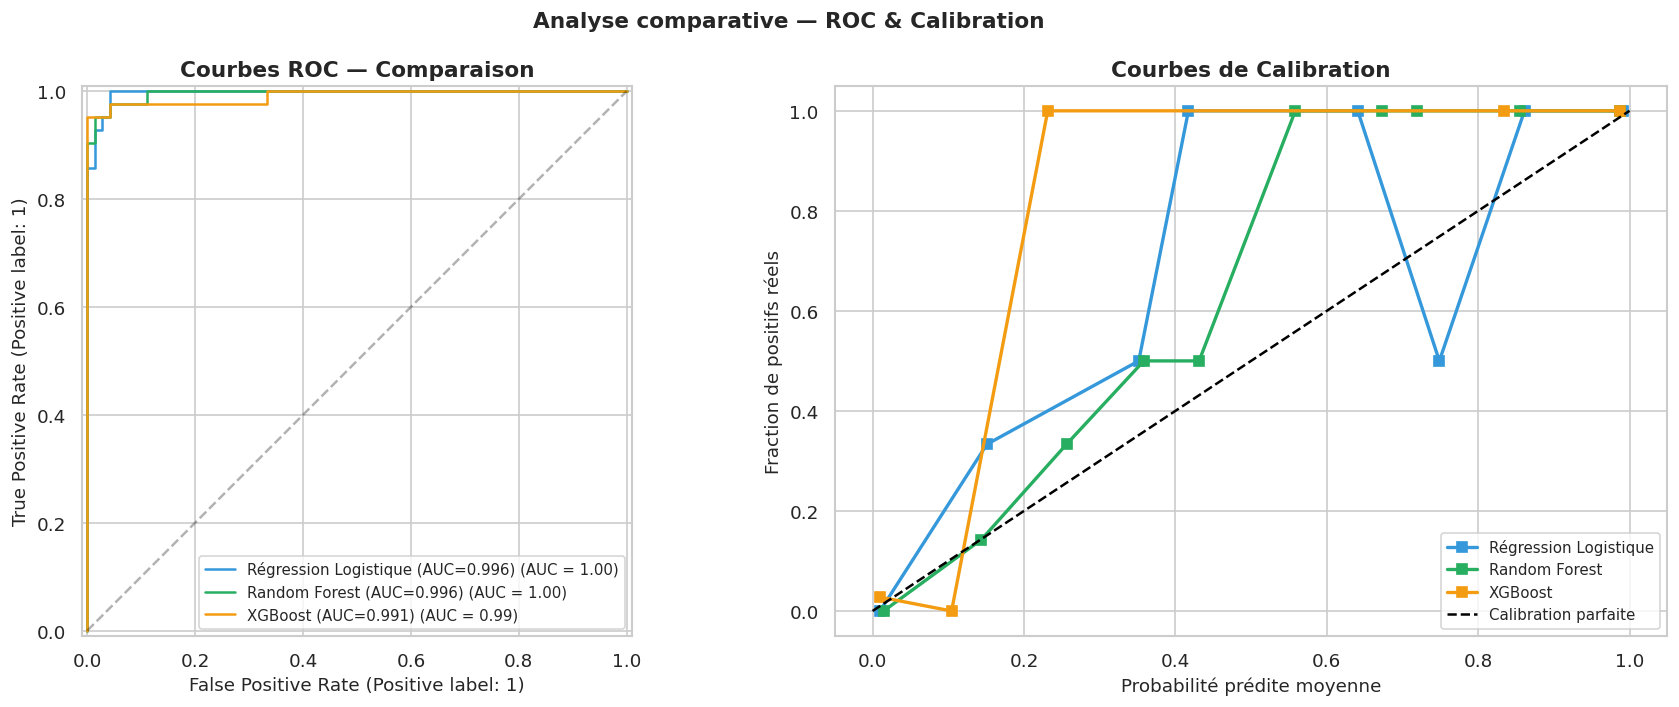

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

probs = [y_prob_lr, y_prob_rf, y_prob_xgb]
for name, prob, color in zip(model_names, probs, colors_comp):
    RocCurveDisplay.from_predictions(y_test, prob, ax=axes[0],
        name=f"{name} (AUC={roc_auc_score(y_test,prob):.3f})", color=color)
axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[0].set_title('Courbes ROC — Comparaison', fontweight='bold')
axes[0].legend(fontsize=9)

cal_data = [(frac_pos_lr, mean_pred_lr), (frac_pos_rf, mean_pred_rf), (frac_pos_xgb, mean_pred_xgb)]
for (name, color), (fp, mp) in zip(zip(model_names, colors_comp), cal_data):
    axes[1].plot(mp, fp, 's-', color=color, label=name, lw=2)
axes[1].plot([0,1],[0,1],'k--', label='Calibration parfaite', lw=1.5)
axes[1].set_xlabel('Probabilité prédite moyenne')
axes[1].set_ylabel('Fraction de positifs réels')
axes[1].set_title('Courbes de Calibration', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Analyse comparative — ROC & Calibration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Courbes Precision–Recall — Comparaison des 3 modèles

La courbe PR est particulièrement informative ici : la priorité clinique est de maximiser le recall (ne manquer aucun cancer malin) tout en surveillant la precision.

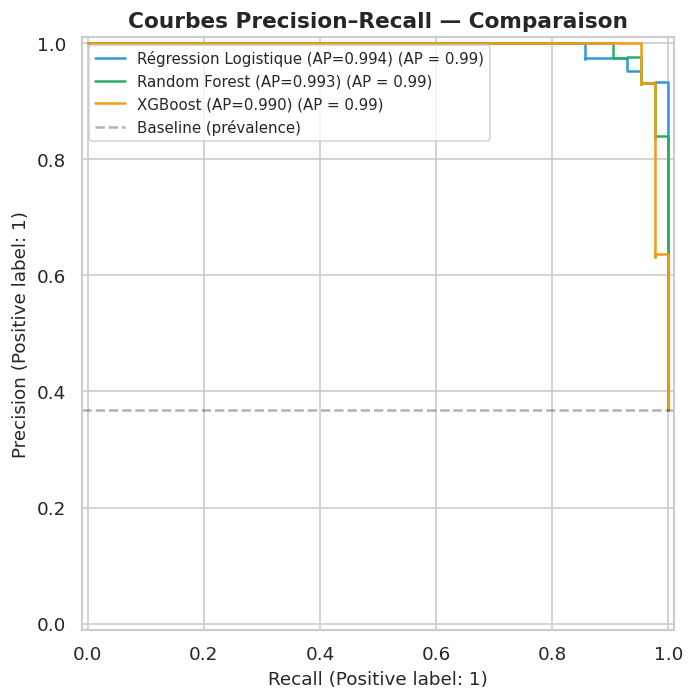

In [42]:
from sklearn.metrics import average_precision_score

fig, ax = plt.subplots(figsize=(8, 6))
for name, prob, color in zip(model_names, probs, colors_comp):
    ap = average_precision_score(y_test, prob)
    PrecisionRecallDisplay.from_predictions(y_test, prob, ax=ax, color=color,
        name=f"{name} (AP={ap:.3f})")
ax.axhline(y_test.mean(), color='k', ls='--', alpha=0.3, label='Baseline (prévalence)')
ax.set_title('Courbes Precision–Recall — Comparaison', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [43]:
best_recall = max(model_names, key=lambda n: all_metrics[n]['Recall'])
best_auc    = max(model_names, key=lambda n: all_metrics[n]['AUC'])
best_brier  = min(model_names, key=lambda n: all_metrics[n]['Brier'])
best_fn     = min(model_names, key=lambda n: fn_dict[n])

print("=" * 65)
print("  VERDICT FINAL — RECOMMANDATION CLINIQUE")
print("=" * 65)
print(f"  Meilleur Recall (FN min)       : {best_recall}")
print(f"  Meilleur AUC                   : {best_auc}")
print(f"  Meilleure Calibration (Brier)  : {best_brier}")
print(f"  Moins de Faux Négatifs         : {best_fn}")
print()
print("  CLASSEMENT FINAL :")
ranked = sorted(model_names,
                key=lambda n: (all_metrics[n]['Recall'],
                               all_metrics[n]['AUC'],
                               -all_metrics[n]['Brier']),
                reverse=True)
for i, name in enumerate(ranked, 1):
    m = all_metrics[name]
    print(f"  {i}. {name:25s}  AUC={m['AUC']:.4f}  "
          f"Recall={m['Recall']:.4f}  FN={fn_dict[name]}  Brier={m['Brier']:.4f}")

# Modèle numérique n°1 (selon Recall > AUC > Brier)
best_overall = ranked[0]
lr_name = 'Régression Logistique'
lr_m = all_metrics[lr_name]
best_m = all_metrics[best_overall]
fn_lr = fn_dict[lr_name]
fn_best = fn_dict[best_overall]

print()
print("  RECOMMANDATION CLINIQUE :")
print()
if best_overall == lr_name:
    print(f"  La Régression Logistique est en tête sur les critères médicaux objectifs.")
    print("  Elle combine le meilleur AUC, une calibration excellente et une")
    print("  interprétabilité directe (odds ratios), ce qui en fait le choix naturel")
    print("  pour un déploiement clinique réglementé (FDA/CE).")
else:
    print(f"  {best_overall} est en tête sur les critères médicaux objectifs")
    print(f"  (Recall={best_m['Recall']:.3f}, FN={fn_best}, Brier={best_m['Brier']:.4f}).")
    print()
    print("  Cependant, le choix final dépend du contexte de déploiement :")
    fn_diff = fn_lr - fn_best
    if fn_diff > 0:
        print(f"  - Si chaque faux négatif supplémentaire est inacceptable ({fn_diff} de plus")
        print(f"    avec LR), {best_overall} s'impose avec SHAP obligatoire.")
    else:
        print(f"  - Le nombre de faux négatifs est identique entre {best_overall} et LR.")
    print()

print()
print("  → Contexte réglementaire / dépistage (population générale) :")
print(f"    Régression Logistique — odds ratios interprétables, calibration")
print("    excellente, standard accepté FDA/CE, auditabilité maximale.")
print()
print("  → Contexte de performance maximale (centre spécialisé, SHAP requis) :")
print(f"    {best_overall} — meilleur profil numérique sur ce test set.")
print("    Chaque prédiction doit être accompagnée d'une explication SHAP.")
print()
print("  ⚠️  Ces modèles sont des outils d'aide à la décision, non des")
print("      dispositifs de diagnostic autonomes. La décision appartient au clinicien.")
print()


  VERDICT FINAL — RECOMMANDATION CLINIQUE
  Meilleur Recall (FN min)       : XGBoost
  Meilleur AUC                   : Régression Logistique
  Meilleure Calibration (Brier)  : XGBoost
  Moins de Faux Négatifs         : XGBoost

  CLASSEMENT FINAL :
  1. XGBoost                    AUC=0.9911  Recall=0.9286  FN=3  Brier=0.0227
  2. Régression Logistique      AUC=0.9964  Recall=0.9048  FN=4  Brier=0.0293
  3. Random Forest              AUC=0.9957  Recall=0.9048  FN=4  Brier=0.0298

  RECOMMANDATION CLINIQUE :

  XGBoost est en tête sur les critères médicaux objectifs
  (Recall=0.929, FN=3, Brier=0.0227).

  Cependant, le choix final dépend du contexte de déploiement :
  - Si chaque faux négatif supplémentaire est inacceptable (1 de plus
    avec LR), XGBoost s'impose avec SHAP obligatoire.


  → Contexte réglementaire / dépistage (population générale) :
    Régression Logistique — odds ratios interprétables, calibration
    excellente, standard accepté FDA/CE, auditabilité maximale.

  →

## 8bis. 🔬 Comparaison des Importances de Variables — Toutes Méthodes

Synthèse visuelle de l'importance accordée à chaque variable retenue (`best_features`) par les différentes approches : statistiques (ANOVA F-score, Information Mutuelle), régularisation (LASSO), et modèles (Random Forest Gini, SHAP moyen absolu sur RF et XGBoost).

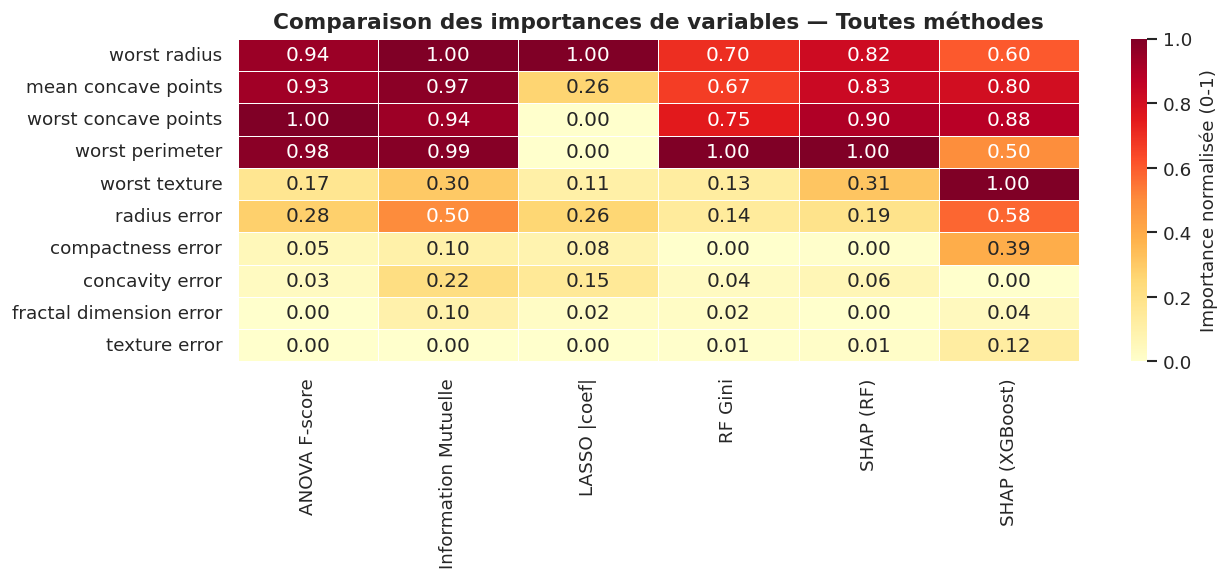

Variable la plus consensuellement importante : worst radius


In [44]:
# ── Recalcule des scores ANOVA / MI sur les best_features (échelle standardisée) ──
anova_scores = pd.Series(
    f_classif(X_train_sel, y_train)[0], index=best_features
)
mi_scores = pd.Series(
    mutual_info_classif(X_train_sel, y_train, random_state=RANDOM_STATE), index=best_features
)
lasso_scores = pd.Series(
    np.abs(coefs.reindex(best_features).values), index=best_features
)
rf_scores = pd.Series(rf.feature_importances_, index=best_features)

if SHAP_OK:
    shap_rf_scores  = pd.Series(np.abs(sv_rf).mean(axis=0), index=best_features)
    shap_xgb_scores = pd.Series(np.abs(shap_vals_xgb).mean(axis=0), index=best_features)
else:
    shap_rf_scores  = pd.Series(0, index=best_features)
    shap_xgb_scores = pd.Series(0, index=best_features)

def normalize(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-12)

importance_df = pd.DataFrame({
    'ANOVA F-score'        : normalize(anova_scores),
    'Information Mutuelle' : normalize(mi_scores),
    'LASSO |coef|'         : normalize(lasso_scores),
    'RF Gini'              : normalize(rf_scores),
    'SHAP (RF)'            : normalize(shap_rf_scores),
    'SHAP (XGBoost)'       : normalize(shap_xgb_scores),
})
importance_df = importance_df.loc[importance_df.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, max(5, len(best_features)*0.45)))
sns.heatmap(importance_df, cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Importance normalisée (0-1)'}, ax=ax)
ax.set_title('Comparaison des importances de variables — Toutes méthodes', fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print("Variable la plus consensuellement importante :", importance_df.mean(axis=1).idxmax())


## 9. 📋 Synthèse & Limites

In [45]:
print("=" * 70)
print("  SYNTHÈSE DU PIPELINE")
print("=" * 70)
print()
print(f"  Dataset          : Wisconsin Breast Cancer ({df.shape[0]} patients, {X.shape[1]} features)")
print(f"  Split            : 80% train ({X_train.shape[0]}) / 20% test ({X_test.shape[0]}) — stratifié")
print(f"  Sélection finale : {best_sel_method} ({len(best_features)} features sur {X.shape[1]})")
print(f"  Déséquilibre     : {(y==1).mean()*100:.1f}% Malin — impact limité, SMOTE testé")
print(f"  Optimisation     : Optuna (bayésien, {N_TRIALS} essais, CV {CV_FOLDS}-fold)")
print()
print("  Résultats sur le jeu de test :")
for name in model_names:
    m = all_metrics[name]
    print(f"    {name:25s}  AUC={m['AUC']:.3f}  Recall={m['Recall']:.3f}  FN={fn_dict[name]}")
print()
print("  LIMITES À MENTIONNER :")
print()
print("  1. Taille du test set : 114 patients — une différence de 1 FN entre")
print("     modèles n'est pas statistiquement significative. Une validation")
print("     externe sur une cohorte indépendante est nécessaire.")
print()
print("  2. Dataset benchmark : Wisconsin BCD est très propre (0 valeur manquante,")
print("     features bien définies). En conditions réelles, la qualité des mesures")
print("     cytologiques peut varier selon l'équipement et l'opérateur.")
print()
print("  3. Sélection de features : les 10 features retenues par Forward Selection")
print("     sont optimisées avec une LR comme estimateur de référence. D'autres")
print("     sous-ensembles pourraient mieux convenir à RF ou XGBoost.")
print()
print("  4. Seuil de décision : tous les modèles utilisent le seuil par défaut (0.5).")
print("     En contexte clinique, abaisser ce seuil augmenterait le Recall au")
print("     détriment de la Precision — arbitrage à discuter avec les cliniciens.")
print()
print("  → Ce projet est un démonstrateur pédagogique. Toute utilisation clinique")
print("    nécessiterait une validation prospective et une certification réglementaire.")

  SYNTHÈSE DU PIPELINE

  Dataset          : Wisconsin Breast Cancer (569 patients, 30 features)
  Split            : 80% train (455) / 20% test (114) — stratifié
  Sélection finale : Forward Selection (10 features sur 30)
  Déséquilibre     : 37.3% Malin — impact limité, SMOTE testé
  Optimisation     : Optuna (bayésien, 60 essais, CV 5-fold)

  Résultats sur le jeu de test :
    Régression Logistique      AUC=0.996  Recall=0.905  FN=4
    Random Forest              AUC=0.996  Recall=0.905  FN=4
    XGBoost                    AUC=0.991  Recall=0.929  FN=3

  LIMITES À MENTIONNER :

  1. Taille du test set : 114 patients — une différence de 1 FN entre
     modèles n'est pas statistiquement significative. Une validation
     externe sur une cohorte indépendante est nécessaire.

  2. Dataset benchmark : Wisconsin BCD est très propre (0 valeur manquante,
     features bien définies). En conditions réelles, la qualité des mesures
     cytologiques peut varier selon l'équipement et l'opérat

## 10. 💾 Sauvegarde du Modèle Final

Export du modèle recommandé (Régression Logistique, voir section 8) avec le scaler et la liste des features, pour permettre un déploiement (API, application Streamlit, etc.) sans réentraînement.

In [46]:
import joblib
import json as _json

# Choix du modèle à déployer = recommandation clinique (1er choix : Régression Logistique)
deployed_model = lr
deployed_name  = "Régression Logistique"

joblib.dump(deployed_model, "breast_cancer_model.pkl")
joblib.dump(scaler, "breast_cancer_scaler.pkl")

with open("breast_cancer_features.json", "w", encoding="utf-8") as f:
    _json.dump(best_features, f, ensure_ascii=False, indent=2)

print(f"✅ Modèle sauvegardé : breast_cancer_model.pkl  ({deployed_name})")
print(f"✅ Scaler sauvegardé : breast_cancer_scaler.pkl")
print(f"✅ Features sauvegardées : breast_cancer_features.json ({len(best_features)} variables)")
print()
print("Pour recharger et prédire sur de nouvelles données :")
print("""
    import joblib, json
    model    = joblib.load('breast_cancer_model.pkl')
    scaler   = joblib.load('breast_cancer_scaler.pkl')
    features = json.load(open('breast_cancer_features.json'))

    # new_data : DataFrame avec les 30 colonnes originales du dataset
    X_new_sc  = pd.DataFrame(scaler.transform(new_data), columns=new_data.columns)
    X_new_sel = X_new_sc[features]
    prediction = model.predict(X_new_sel)
    probability = model.predict_proba(X_new_sel)[:, 1]
""")


✅ Modèle sauvegardé : breast_cancer_model.pkl  (Régression Logistique)
✅ Scaler sauvegardé : breast_cancer_scaler.pkl
✅ Features sauvegardées : breast_cancer_features.json (10 variables)

Pour recharger et prédire sur de nouvelles données :

    import joblib, json
    model    = joblib.load('breast_cancer_model.pkl')
    scaler   = joblib.load('breast_cancer_scaler.pkl')
    features = json.load(open('breast_cancer_features.json'))

    # new_data : DataFrame avec les 30 colonnes originales du dataset
    X_new_sc  = pd.DataFrame(scaler.transform(new_data), columns=new_data.columns)
    X_new_sel = X_new_sc[features]
    prediction = model.predict(X_new_sel)
    probability = model.predict_proba(X_new_sel)[:, 1]

